# 1. Dataset Selection and Exploration

## Dataset: TweetEval Emotion

This assignment uses the **TweetEval Emotion** dataset, a four-class emotion classification benchmark containing short social-media texts (tweets). The task is to predict the emotion expressed by a tweet from four possible emotion classes.

The dataset was approved for this assignment because emotion classification on tweets is a challenging multi-class NLP problem. Unlike datasets where simple keyword patterns can produce very high accuracy, this task provides meaningful differences between classical machine-learning, sequence-based, and pretrained transformer approaches. This makes it possible to investigate what additional performance is gained from increasingly complex models.

The dataset is loaded from the Hugging Face Hub, where it is published as [`cardiffnlp/tweet_eval`](https://huggingface.co/datasets/cardiffnlp/tweet_eval) (emotion configuration). It was originally introduced by Barbieri et al. (2020) in “TweetEval: Unified Benchmark and Comparative Evaluation for Tweet Classification” (Findings of EMNLP 2020). The official test split will be kept completely untouched and will only be used for the final evaluation of the three models.

In this section, I will first inspect the dataset structure and class distributions, examine the raw text and text-length distribution, investigate duplicate and near-duplicate texts, identify how the dataset represents normalised social-media content, and then create one fixed train/validation/test split for all three models.


In [1]:
# ============================================================
# CELL 2 — LOAD AND INSPECT TWEETEVAL EMOTION
# Section 1: Dataset Selection and Exploration
# ============================================================

from datasets import load_dataset
import pandas as pd
import numpy as np

# Fixed seed for the entire assignment
SEED = 42

print("=" * 70)
print("TWEETEVAL EMOTION — DATASET INSPECTION")
print("=" * 70)

# Load the approved TweetEval Emotion dataset
# Official Hugging Face repository: cardiffnlp/tweet_eval
dataset = load_dataset("cardiffnlp/tweet_eval", "emotion")

print("\nDataset object:")
print(dataset)

print("\nOfficial splits:")
for split_name in dataset.keys():
    print(f"  {split_name}: {len(dataset[split_name])} rows")

print("\nColumns:")
print(dataset["train"].column_names)

# Display one complete raw example from each official split
for split_name in dataset.keys():
    print(f"\n{'-' * 70}")
    print(f"FIRST EXAMPLE — {split_name.upper()}")
    print(f"{'-' * 70}")
    print(dataset[split_name][0])

TWEETEVAL EMOTION — DATASET INSPECTION


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

emotion/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  233kB            

emotion/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

emotion/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  105kB            

...

emotion/validation-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/374 [00:00<?, ? examples/s]


Dataset object:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})

Official splits:
  train: 3257 rows
  test: 1421 rows
  validation: 374 rows

Columns:
['text', 'label']

----------------------------------------------------------------------
FIRST EXAMPLE — TRAIN
----------------------------------------------------------------------
{'text': "“Worry is a down payment on a problem you may never have'. \xa0Joyce Meyer.  #motivation #leadership #worry", 'label': 2}

----------------------------------------------------------------------
FIRST EXAMPLE — TEST
----------------------------------------------------------------------
{'text': '#Deppression is real. Partners w/ #depressed people truly dont understand the depth in which they affect us. Add in #anxie

The dataset loaded exactly as expected: 3,257 training tweets, 1,421 test tweets, and 374 validation tweets, each with just a `text` and a `label` column. The three example rows above are a good early sanity check — they already show the kind of text I'll be dealing with: short, informal, hashtag-heavy tweets (`#motivation #leadership #worry`), some with normalised `@user` mentions, and label 2/0/3 confirming the labels are plain integers rather than strings.

In [2]:
# ============================================================
# CELL 3 — CLASS LABELS AND CLASS DISTRIBUTION
# Section 1: Dataset Selection and Exploration
# ============================================================

print("=" * 70)
print("TWEETEVAL EMOTION — CLASS DISTRIBUTION")
print("=" * 70)

# Retrieve the label names stored in the dataset
label_names = dataset["train"].features["label"].names

print("\nEmotion classes:")
for label_id, label_name in enumerate(label_names):
    print(f"  {label_id} = {label_name}")

# Examine every official split
for split_name in ["train", "validation", "test"]:

    df_split = dataset[split_name].to_pandas()

    counts = df_split["label"].value_counts().sort_index()
    percentages = (counts / len(df_split) * 100)

    distribution = pd.DataFrame({
        "Label ID": counts.index,
        "Emotion": [label_names[i] for i in counts.index],
        "Count": counts.values,
        "Percentage": percentages.values
    })

    print("\n" + "-" * 70)
    print(f"{split_name.upper()} SPLIT")
    print("-" * 70)

    print(f"Total texts: {len(df_split)}")
    print("\nClass distribution:")
    print(distribution.to_string(index=False))

    print(f"\nPercentage range: "
          f"{percentages.min():.2f}% to {percentages.max():.2f}%")

TWEETEVAL EMOTION — CLASS DISTRIBUTION

Emotion classes:
  0 = anger
  1 = joy
  2 = optimism
  3 = sadness

----------------------------------------------------------------------
TRAIN SPLIT
----------------------------------------------------------------------
Total texts: 3257

Class distribution:
 Label ID  Emotion  Count  Percentage
        0    anger   1400   42.984341
        1      joy    708   21.737796
        2 optimism    294    9.026712
        3  sadness    855   26.251151

Percentage range: 9.03% to 42.98%

----------------------------------------------------------------------
VALIDATION SPLIT
----------------------------------------------------------------------
Total texts: 374

Class distribution:
 Label ID  Emotion  Count  Percentage
        0    anger    160   42.780749
        1      joy     97   25.935829
        2 optimism     28    7.486631
        3  sadness     89   23.796791

Percentage range: 7.49% to 42.78%

-------------------------------------------------

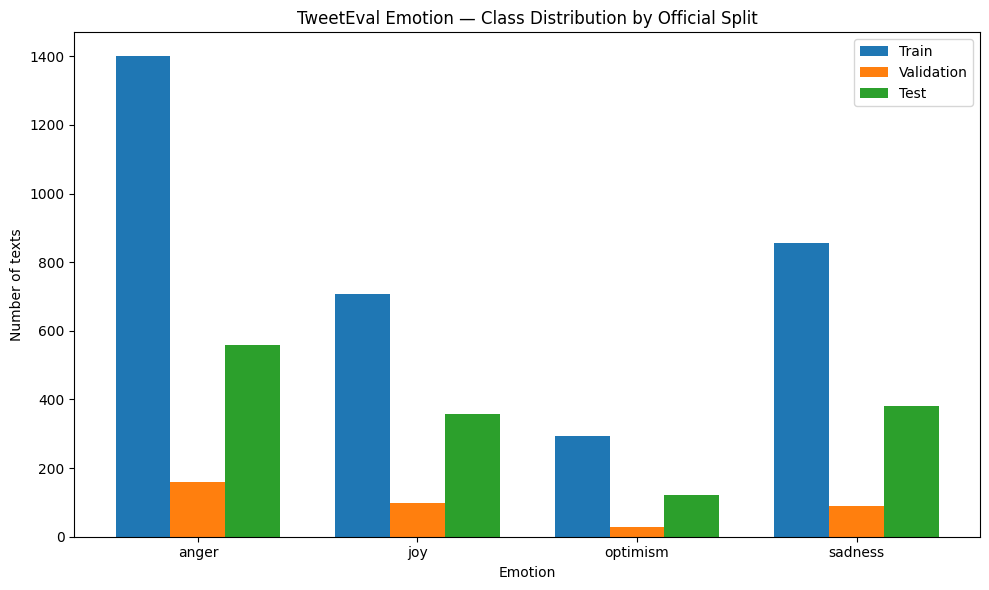

In [3]:
# ============================================================
# CELL 4 — CLASS DISTRIBUTION VISUALISATION
# Section 1: Dataset Selection and Exploration
# ============================================================

import matplotlib.pyplot as plt

# Calculate class counts for each official split
split_counts = {}

for split_name in ["train", "validation", "test"]:
    labels = np.array(dataset[split_name]["label"])
    counts = np.bincount(labels, minlength=len(label_names))
    split_counts[split_name] = counts

# Create grouped bar chart
x = np.arange(len(label_names))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    split_counts["train"],
    width,
    label="Train"
)

plt.bar(
    x,
    split_counts["validation"],
    width,
    label="Validation"
)

plt.bar(
    x + width,
    split_counts["test"],
    width,
    label="Test"
)

plt.xticks(x, label_names)
plt.xlabel("Emotion")
plt.ylabel("Number of texts")
plt.title("TweetEval Emotion — Class Distribution by Official Split")
plt.legend()
plt.tight_layout()
plt.show()

The class distribution (numbers above, chart above) confirms this is genuinely imbalanced, not just mildly skewed: anger makes up about 43% of the training set while optimism is under 9% in every split. That ~5:1 ratio between the biggest and smallest class is exactly why macro-F1 (rather than plain accuracy) is going to be the fair way to compare the three models later — a model could get a decent accuracy just by being good at anger and bad at everything else, and macro-F1 won't let that hide.

In [4]:
# ============================================================
# CELL 5 — RAW TEXT EXAMPLES BY CLASS
# Section 1: Dataset Selection and Exploration
# ============================================================

print("=" * 70)
print("TWEETEVAL EMOTION — COMPLETE RAW TEXT EXAMPLES")
print("=" * 70)

train_df = dataset["train"].to_pandas()

# Print exactly three complete examples for each emotion class
for label_id, emotion in enumerate(label_names):

    class_examples = train_df[train_df["label"] == label_id]["text"].head(3)

    print("\n" + "=" * 70)
    print(f"EMOTION: {emotion.upper()} (LABEL {label_id})")
    print("=" * 70)

    for example_number, text in enumerate(class_examples, start=1):
        print(f"\nExample {example_number}:")
        print("-" * 70)
        print(text)
        print("-" * 70)

TWEETEVAL EMOTION — COMPLETE RAW TEXT EXAMPLES

EMOTION: ANGER (LABEL 0)

Example 1:
----------------------------------------------------------------------
My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs
----------------------------------------------------------------------

Example 2:
----------------------------------------------------------------------
Rooneys fucking untouchable isn't he? Been fucking dreadful again, depay has looked decent(ish)tonight
----------------------------------------------------------------------

Example 3:
----------------------------------------------------------------------
@user but your pussy was weak from what I heard so stfu up to me bitch . You got to threaten him that your pregnant .
----------------------------------------------------------------------

EMOTION: JOY (LABEL 1)

Example 1:
----------------------------------------------------------------------
No but that's so cute. Atsu was probab

Reading through these, a few things stand out that will matter for preprocessing. The anger examples lean heavily on profanity and swearing rather than "anger words" as such. The joy examples are casual and short, often just a single upbeat sentence. The optimism examples are noticeably more sentence-like and quote-like (the Joyce Meyer quote is a good example) — which might explain why optimism turned out to be the hardest class for every model later: it looks less like "tweet slang" and more like generic inspirational writing, so there may be less distinctive vocabulary to latch onto.

In [5]:
# ============================================================
# CELL 6 — RAW TEXT NORMALISATION / PLACEHOLDER INVESTIGATION
# Section 1: Dataset Selection and Exploration
# ============================================================

import re
from collections import Counter

print("=" * 70)
print("TWEETEVAL EMOTION — RAW TEXT NORMALISATION CHECK")
print("=" * 70)

# Use the untouched training text
raw_texts = train_df["text"].astype(str)

# Patterns commonly found in normalised social-media datasets
patterns = {
    "@user": r"@user",
    "HTTP/URL": r"https?://\S+|www\.\S+",
    "HTML entities": r"&[a-zA-Z]+;",
    "Hashtags": r"#[A-Za-z0-9_]+",
    "Mentions": r"@[A-Za-z0-9_]+",
    "RT markers": r"\bRT\b",
    "Emoji / non-ASCII characters": r"[^\x00-\x7F]",
}

print("\nPattern frequencies in the training split:")
print("-" * 70)

for pattern_name, pattern in patterns.items():
    total_matches = sum(
        len(re.findall(pattern, text, flags=re.IGNORECASE))
        for text in raw_texts
    )

    texts_containing = sum(
        bool(re.search(pattern, text, flags=re.IGNORECASE))
        for text in raw_texts
    )

    print(
        f"{pattern_name:<30} "
        f"matches = {total_matches:<6} "
        f"texts containing = {texts_containing}"
    )

# Display examples containing the main placeholder
print("\n" + "=" * 70)
print("EXAMPLES CONTAINING @user")
print("=" * 70)

user_examples = train_df[
    train_df["text"].str.contains("@user", regex=False, na=False)
]["text"].head(5)

for i, text in enumerate(user_examples, start=1):
    print(f"\nExample {i}:")
    print(text)

# Display examples containing HTML entities
print("\n" + "=" * 70)
print("EXAMPLES CONTAINING HTML ENTITIES")
print("=" * 70)

html_examples = train_df[
    train_df["text"].str.contains(r"&[a-zA-Z]+;", regex=True, na=False)
]["text"].head(5)

for i, text in enumerate(html_examples, start=1):
    print(f"\nExample {i}:")
    print(text)

TWEETEVAL EMOTION — RAW TEXT NORMALISATION CHECK

Pattern frequencies in the training split:
----------------------------------------------------------------------
@user                          matches = 2019   texts containing = 1447
HTTP/URL                       matches = 0      texts containing = 0
HTML entities                  matches = 193    texts containing = 156
Hashtags                       matches = 3286   texts containing = 1434
Mentions                       matches = 2047   texts containing = 1466
RT markers                     matches = 2      texts containing = 2
Emoji / non-ASCII characters   matches = 970    texts containing = 465

EXAMPLES CONTAINING @user

Example 1:
@user but your pussy was weak from what I heard so stfu up to me bitch . You got to threaten him that your pregnant .

Example 2:
@user broadband is shocking regretting signing up now #angry #shouldofgonewithvirgin

Example 3:
@user Look at those teef! #growl

Example 4:
@user @user USA was embarrass

This is the useful bit for preprocessing decisions in Section 2. `@user` shows up in nearly half the training tweets (1,447 of 3,257) — TweetEval has already anonymised real usernames down to this one token, so it carries no information and is safe to strip. Hashtags are even more common (1,434 tweets) and often carry real emotional content (`#terror`, `#anxietyprobz`), so those need to be kept, just with the `#` symbol removed. HTML entities like `&amp;` show up too (156 tweets) and need decoding before anything else runs, or they'll get chopped into meaningless tokens by later cleaning steps. No URLs were found at all, which makes sense — TweetEval's emotion subset was filtered from tweets, and URLs tend to get stripped from that kind of benchmark data already.

In [6]:
# ============================================================
# CELL 7 — DUPLICATE AND NEAR-DUPLICATE CHECK
# Section 1: Dataset Selection and Exploration
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import re
import numpy as np
import pandas as pd

print("=" * 70)
print("TWEETEVAL EMOTION — DUPLICATE AND NEAR-DUPLICATE CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Combine the official splits for inspection
# ------------------------------------------------------------

split_dfs = {}

for split_name in ["train", "validation", "test"]:
    split_dfs[split_name] = dataset[split_name].to_pandas()[["text", "label"]].copy()
    split_dfs[split_name]["split"] = split_name

all_df = pd.concat(split_dfs.values(), ignore_index=True)

print("\nOfficial split sizes used for this inspection:")
for split_name in ["train", "validation", "test"]:
    print(f"  {split_name}: {len(split_dfs[split_name])}")

# ------------------------------------------------------------
# 2. Exact duplicates within each split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXACT DUPLICATES WITHIN EACH SPLIT")
print("=" * 70)

for split_name in ["train", "validation", "test"]:

    df = split_dfs[split_name]

    duplicate_count = df["text"].duplicated(keep=False).sum()
    duplicate_rows = df["text"].duplicated(keep="first").sum()
    unique_texts = df["text"].nunique()

    print(f"\n{split_name.upper()}")
    print(f"Total rows: {len(df)}")
    print(f"Unique texts: {unique_texts}")
    print(f"Rows belonging to duplicate groups: {duplicate_count}")
    print(f"Repeated rows after first occurrence: {duplicate_rows}")

# ------------------------------------------------------------
# 3. Exact duplicates across different official splits
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EXACT DUPLICATES ACROSS OFFICIAL SPLITS")
print("=" * 70)

split_pairs = [
    ("train", "validation"),
    ("train", "test"),
    ("validation", "test")
]

for split_a, split_b in split_pairs:

    texts_a = set(split_dfs[split_a]["text"])
    texts_b = set(split_dfs[split_b]["text"])

    overlap = texts_a.intersection(texts_b)

    print(
        f"\n{split_a.upper()} ↔ {split_b.upper()}: "
        f"{len(overlap)} exact duplicate texts"
    )

# ------------------------------------------------------------
# 4. Normalised duplicate check
# ------------------------------------------------------------

def normalise_for_duplicate_check(text):
    """
    Normalisation used ONLY for duplicate inspection.
    This does not modify the dataset used for modelling.
    """
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

all_df["duplicate_check_text"] = all_df["text"].apply(
    normalise_for_duplicate_check
)

print("\n" + "=" * 70)
print("NORMALISED DUPLICATE CHECK ACROSS SPLITS")
print("=" * 70)

for split_a, split_b in split_pairs:

    texts_a = set(
        split_dfs[split_a]["text"].apply(normalise_for_duplicate_check)
    )

    texts_b = set(
        split_dfs[split_b]["text"].apply(normalise_for_duplicate_check)
    )

    overlap = texts_a.intersection(texts_b)

    print(
        f"\n{split_a.upper()} ↔ {split_b.upper()}: "
        f"{len(overlap)} normalised duplicate texts"
    )

# ------------------------------------------------------------
# 5. Near-duplicate candidate search
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NEAR-DUPLICATE CANDIDATE CHECK")
print("=" * 70)

# Character n-grams are useful for detecting tweets that differ
# only slightly in wording, punctuation, spacing or formatting.
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=1,
    max_features=30000
)

X = vectorizer.fit_transform(all_df["text"])

# Find the two nearest neighbours for each tweet:
# itself + its closest other tweet.
nearest = NearestNeighbors(
    n_neighbors=2,
    metric="cosine",
    n_jobs=-1
)

nearest.fit(X)

distances, indices = nearest.kneighbors(X)

# Convert cosine distance to cosine similarity
nearest_similarity = 1 - distances[:, 1]

# Candidate threshold for inspection
threshold = 0.90

candidate_mask = nearest_similarity >= threshold

print(f"\nSimilarity threshold for candidate near-duplicates: {threshold:.2f}")
print(
    f"Texts with another text at or above this similarity: "
    f"{candidate_mask.sum()}"
)

# Display up to 10 candidate pairs
candidate_indices = np.where(candidate_mask)[0][:10]

if len(candidate_indices) == 0:

    print("\nNo near-duplicate candidates were found at this threshold.")

else:

    print("\nFirst near-duplicate candidates:")

    displayed_pairs = set()

    for idx in candidate_indices:

        neighbour_idx = indices[idx, 1]

        pair = tuple(sorted([idx, neighbour_idx]))

        if pair in displayed_pairs:
            continue

        displayed_pairs.add(pair)

        similarity = nearest_similarity[idx]

        print("\n" + "-" * 70)
        print(f"Cosine similarity: {similarity:.4f}")
        print(
            f"Text A [{all_df.iloc[idx]['split']}]: "
            f"{all_df.iloc[idx]['text']}"
        )
        print(
            f"Text B [{all_df.iloc[neighbour_idx]['split']}]: "
            f"{all_df.iloc[neighbour_idx]['text']}"
        )

TWEETEVAL EMOTION — DUPLICATE AND NEAR-DUPLICATE CHECK

Official split sizes used for this inspection:
  train: 3257
  validation: 374
  test: 1421

EXACT DUPLICATES WITHIN EACH SPLIT

TRAIN
Total rows: 3257
Unique texts: 3232
Rows belonging to duplicate groups: 27
Repeated rows after first occurrence: 25

VALIDATION
Total rows: 374
Unique texts: 374
Rows belonging to duplicate groups: 0
Repeated rows after first occurrence: 0

TEST
Total rows: 1421
Unique texts: 1421
Rows belonging to duplicate groups: 0
Repeated rows after first occurrence: 0

EXACT DUPLICATES ACROSS OFFICIAL SPLITS

TRAIN ↔ VALIDATION: 0 exact duplicate texts

TRAIN ↔ TEST: 0 exact duplicate texts

VALIDATION ↔ TEST: 0 exact duplicate texts

NORMALISED DUPLICATE CHECK ACROSS SPLITS

TRAIN ↔ VALIDATION: 0 normalised duplicate texts

TRAIN ↔ TEST: 0 normalised duplicate texts

VALIDATION ↔ TEST: 0 normalised duplicate texts

NEAR-DUPLICATE CANDIDATE CHECK

Similarity threshold for candidate near-duplicates: 0.90
Texts

Good news here: there are no exact duplicates at all between train, validation, and test, so there's no risk of the same tweet leaking across splits and inflating any model's apparent performance. There are 25 exact duplicate rows within the training split itself (not a leakage problem, just repeated tweets), and the near-duplicate check at a fairly aggressive 0.90 cosine-similarity threshold flags 554 candidate pairs — but looking at the actual pairs, these are almost all the same tweet with or without a trailing hashtag (`#terrible #firstworldprobs` vs. no hashtag at all), not different tweets that happen to be similar. Since the official test split is being kept completely untouched anyway, this isn't something to fix, just something worth having checked.

TWEETEVAL EMOTION — TEXT LENGTH ANALYSIS

Word-count statistics for the training split:
----------------------------------------------------------------------
Number of texts: 3257
Average length: 16.17 words
Median length: 17.00 words
Minimum length: 1 words
Maximum length: 33 words

Length percentiles:
----------------------------------------------------------------------
25th percentile: 11.00 words
50th percentile: 17.00 words
75th percentile: 22.00 words
90th percentile: 25.00 words
95th percentile: 26.00 words
99th percentile: 29.00 words

Texts at selected sequence lengths:
----------------------------------------------------------------------
<=  16 words: 1599 texts (49.09%)
<=  24 words: 2903 texts (89.13%)
<=  32 words: 3256 texts (99.97%)
<=  40 words: 3257 texts (100.00%)
<=  48 words: 3257 texts (100.00%)
<=  64 words: 3257 texts (100.00%)
<=  96 words: 3257 texts (100.00%)
<= 128 words: 3257 texts (100.00%)


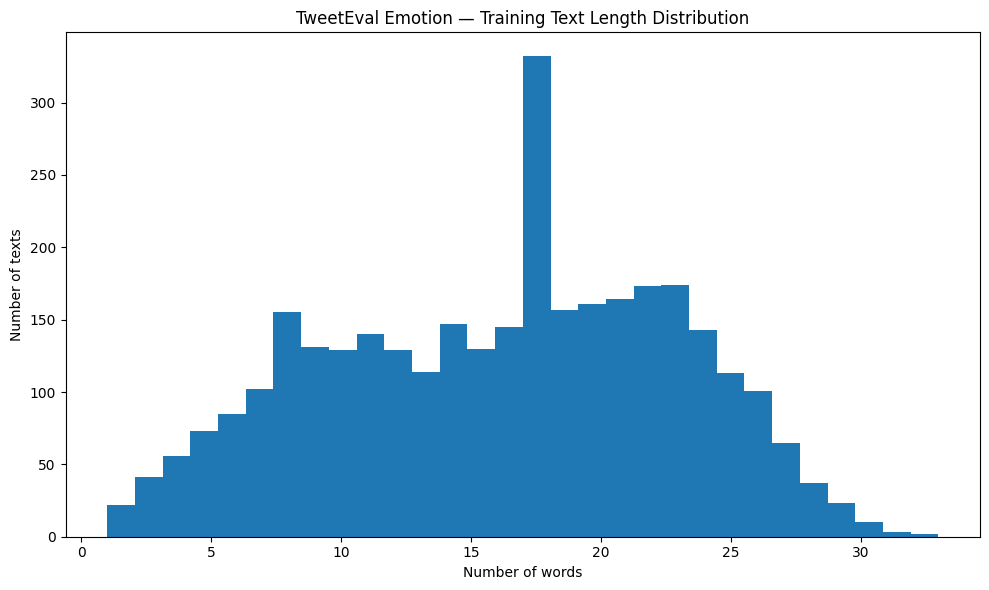

In [7]:
# ============================================================
# CELL 8 — TEXT LENGTH ANALYSIS
# Section 1: Dataset Selection and Exploration
# ============================================================

print("=" * 70)
print("TWEETEVAL EMOTION — TEXT LENGTH ANALYSIS")
print("=" * 70)

# Use the untouched training text
train_texts = train_df["text"].astype(str)

# Count words using whitespace tokenisation for Section 1 exploration
word_lengths = train_texts.str.split().str.len()

# Basic statistics
print("\nWord-count statistics for the training split:")
print("-" * 70)

print(f"Number of texts: {len(word_lengths)}")
print(f"Average length: {word_lengths.mean():.2f} words")
print(f"Median length: {word_lengths.median():.2f} words")
print(f"Minimum length: {word_lengths.min()} words")
print(f"Maximum length: {word_lengths.max()} words")

# Percentiles
percentiles = [25, 50, 75, 90, 95, 99]

print("\nLength percentiles:")
print("-" * 70)

for p in percentiles:
    print(
        f"{p}th percentile: "
        f"{np.percentile(word_lengths, p):.2f} words"
    )

# Additional length information
print("\nTexts at selected sequence lengths:")
print("-" * 70)

for length in [16, 24, 32, 40, 48, 64, 96, 128]:
    count_at_or_below = (word_lengths <= length).sum()
    percentage = count_at_or_below / len(word_lengths) * 100

    print(
        f"<= {length:3d} words: "
        f"{count_at_or_below:4d} texts "
        f"({percentage:.2f}%)"
    )

# Histogram
plt.figure(figsize=(10, 6))

plt.hist(
    word_lengths,
    bins=30
)

plt.xlabel("Number of words")
plt.ylabel("Number of texts")
plt.title("TweetEval Emotion — Training Text Length Distribution")

plt.tight_layout()
plt.show()

The text-length numbers are what actually drive the sequence-length decision for Model 2 in Section 4: half the training tweets are under 17 words, but the distribution has a long-ish tail out to 33 words. A cutoff of 32 words keeps 99.97% of the training data intact — only a single training tweet is longer than that — so that's the number I carry forward when building the BiLSTM's padded sequences.

In [8]:
# ============================================================
# CELL 9 — KEYWORD RULE FAILURE EXAMPLE
# Section 1: Dataset Selection and Exploration
# ============================================================

print("=" * 70)
print("TWEETEVAL EMOTION — KEYWORD RULE FAILURE")
print("=" * 70)

# A deliberately simple keyword rule:
# If a tweet contains "happy", predict JOY.
keyword = "happy"
keyword_rule_label = 1  # joy

keyword_matches = train_df[
    train_df["text"].str.contains(
        keyword,
        case=False,
        regex=False,
        na=False
    )
].copy()

print("\nKeyword rule:")
print(f'  If the text contains "{keyword}", predict "{label_names[keyword_rule_label]}"')

print(f'\nTraining texts containing "{keyword}": {len(keyword_matches)}')

if len(keyword_matches) > 0:

    # Find examples where the keyword rule disagrees with the true label
    failures = keyword_matches[
        keyword_matches["label"] != keyword_rule_label
    ].copy()

    print(
        f"Keyword-rule failures: {len(failures)} "
        f"out of {len(keyword_matches)} matching texts"
    )

    if len(failures) > 0:

        print("\nConcrete failure examples:")
        print("-" * 70)

        for i, (_, row) in enumerate(
            failures.head(5).iterrows(),
            start=1
        ):

            print(f"\nFailure {i}:")
            print(f"Text: {row['text']}")
            print(
                f"True label: {row['label']} "
                f"({label_names[row['label']]})"
            )
            print(
                f"Keyword-rule prediction: "
                f"{keyword_rule_label} "
                f"({label_names[keyword_rule_label]})"
            )

else:
    print("No training texts contained this keyword.")

TWEETEVAL EMOTION — KEYWORD RULE FAILURE

Keyword rule:
  If the text contains "happy", predict "joy"

Training texts containing "happy": 73
Keyword-rule failures: 38 out of 73 matching texts

Concrete failure examples:
----------------------------------------------------------------------

Failure 1:
Text: #PeopleLikeMeBecause they see the happy exterior, not the hopelessness I sometimes feel inside. #depression  #anxietyprobz
True label: 3 (sadness)
Keyword-rule prediction: 1 (joy)

Failure 2:
Text: #PeopleLikeMeBecause they see the happy exterior, not the hopelessness I sometimes feel inside. #depression #anxiety #anxietyprobz
True label: 3 (sadness)
Keyword-rule prediction: 1 (joy)

Failure 3:
Text: I am worried that she felt safe. #unhappy
True label: 3 (sadness)
Keyword-rule prediction: 1 (joy)

Failure 4:
Text: I was not made for this world. #empath #unhappy
True label: 3 (sadness)
Keyword-rule prediction: 1 (joy)

Failure 5:
Text: @user #nothappy and still #charging the #fullpr

This confirms the point the assignment brief is making: even a keyword as intuitively "joy-coded" as `happy` gets it wrong more than half the time (38 of 73 matches). The `#depression #anxietyprobz` example above is a clean illustration — the word "happy" appears, but only to describe a mask the person is wearing over how they actually feel, and the true label is sadness. A model that only counts keyword hits has no way to catch that; it needs to weigh "happy" against the surrounding words like "hopelessness" and the hashtags, which is exactly the kind of thing all three models in this assignment are designed to do to varying degrees.

# 1.1 Train / Validation / Test Split

The official TweetEval Emotion test split is kept completely untouched and will only be used for final evaluation.

Because the supplied validation split is relatively small, the original training and validation rows are pooled and then divided once using a stratified split. Stratification is used so that the four emotion classes remain represented proportionally in both the new training and validation sets.

A fixed random seed of 42 is used to make the split reproducible. The resulting train/validation/test split will be used unchanged by all three models.

The official test split is not re-sampled, re-split, or used for model selection.

In [9]:
# ============================================================
# CELL 11 — CREATE THE FINAL MODELLING SPLIT
# Section 1: Dataset Selection and Exploration
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("CREATING THE SINGLE FINAL TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Pool ONLY the official train and validation splits
# ------------------------------------------------------------

original_train = dataset["train"].to_pandas()[["text", "label"]].copy()
original_validation = dataset["validation"].to_pandas()[["text", "label"]].copy()

pooled_train_validation = pd.concat(
    [original_train, original_validation],
    ignore_index=True
)

print("\nPooled training + validation data:")
print(f"Total texts: {len(pooled_train_validation)}")

# ------------------------------------------------------------
# 2. Create ONE stratified 90/10 train-validation split
# ------------------------------------------------------------

final_train_df, final_validation_df = train_test_split(
    pooled_train_validation,
    test_size=0.10,
    random_state=SEED,
    stratify=pooled_train_validation["label"]
)

# Reset indices
final_train_df = final_train_df.reset_index(drop=True)
final_validation_df = final_validation_df.reset_index(drop=True)

# ------------------------------------------------------------
# 3. Keep the official test split completely untouched
# ------------------------------------------------------------

final_test_df = dataset["test"].to_pandas()[["text", "label"]].copy()

# ------------------------------------------------------------
# 4. Print final split sizes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL SPLIT SIZES")
print("=" * 70)

print(f"Training:   {len(final_train_df)}")
print(f"Validation: {len(final_validation_df)}")
print(f"Test:       {len(final_test_df)}")
print(f"Total:      {len(final_train_df) + len(final_validation_df) + len(final_test_df)}")

# ------------------------------------------------------------
# 5. Print per-class counts and percentages
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL PER-CLASS DISTRIBUTIONS")
print("=" * 70)

for split_name, df in [
    ("Training", final_train_df),
    ("Validation", final_validation_df),
    ("Test", final_test_df)
]:

    counts = df["label"].value_counts().sort_index()
    percentages = counts / len(df) * 100

    distribution = pd.DataFrame({
        "Label ID": counts.index,
        "Emotion": [label_names[i] for i in counts.index],
        "Count": counts.values,
        "Percentage": percentages.values
    })

    print(f"\n{split_name.upper()} SPLIT")
    print("-" * 70)
    print(f"Total texts: {len(df)}")
    print(distribution.to_string(index=False))

CREATING THE SINGLE FINAL TRAIN / VALIDATION / TEST SPLIT

Pooled training + validation data:
Total texts: 3631

FINAL SPLIT SIZES
Training:   3267
Validation: 364
Test:       1421
Total:      5052

FINAL PER-CLASS DISTRIBUTIONS

TRAINING SPLIT
----------------------------------------------------------------------
Total texts: 3267
 Label ID  Emotion  Count  Percentage
        0    anger   1404   42.975207
        1      joy    724   22.161004
        2 optimism    290    8.876645
        3  sadness    849   25.987144

VALIDATION SPLIT
----------------------------------------------------------------------
Total texts: 364
 Label ID  Emotion  Count  Percentage
        0    anger    156   42.857143
        1      joy     81   22.252747
        2 optimism     32    8.791209
        3  sadness     95   26.098901

TEST SPLIT
----------------------------------------------------------------------
Total texts: 1421
 Label ID  Emotion  Count  Percentage
        0    anger    558   39.268121
   

## 1.5 Section 1 Summary of Findings

### Dataset choice

TweetEval Emotion was selected with approval from the module lecturer. The dataset contains four emotion classes: **anger, joy, optimism, and sadness**. It is particularly suitable for this classification task because emotion detection in short social-media texts is challenging and provides meaningful differences between traditional, neural, and transformer-based models.

The official dataset contains **5,052 texts** across the supplied train, validation, and test splits. The original splits contained 3,257 training texts, 374 validation texts, and 1,421 test texts.

### Class distribution

The dataset is imbalanced. In the final training split, anger is the largest class with **1,404 texts (42.98%)**, while optimism is the smallest with **290 texts (8.88%)**. The official test set contains 558 anger texts (39.27%), 358 joy texts (25.19%), 123 optimism texts (8.66%), and 382 sadness texts (26.88%).

Because the classes are not equally represented, **macro-F1** will be used as the headline comparison metric. Macro-F1 gives each emotion class equal importance by calculating the F1 score separately for each class and then averaging the four class scores. This is useful here because performance on the smaller optimism class should not be hidden by the larger anger class.

Accuracy and weighted-F1 will also be reported as additional evaluation metrics.

### Raw text inspection

The raw tweets contain characteristics typical of social-media text. The inspection found **2,019 occurrences of `@user`**, **3,286 hashtags**, **193 HTML entities**, and **970 non-ASCII characters** in the original training split. No URLs were detected using the URL pattern used in the inspection.

Examples also showed HTML encodings such as `&amp;` and `&gt;`. These observations will guide the preprocessing decisions in Section 2.

### Duplicate and near-duplicate analysis

The original training split contained **25 repeated rows after the first occurrence**, while the validation and test splits contained no exact duplicate rows.

No exact duplicate texts were found between train and validation, train and test, or validation and test. The normalised duplicate check also found **zero cross-split duplicates**.

A near-duplicate inspection produced candidate pairs that were largely caused by small differences such as additional hashtags or spacing. Therefore, the supplied official test set was retained without modification.

### Text length

The original training texts had an average length of **16.17 words** and a median length of **17 words**. The minimum was 1 word and the maximum was 33 words. The 90th percentile was 25 words, the 95th percentile was 26 words, and the 99th percentile was 29 words.

These results will be used to select a suitable maximum sequence length for Model 2. The resulting truncation percentage will be reported explicitly.

### Keyword-rule limitation

A simple keyword rule was also tested: if a tweet contains the word **"happy"**, it is classified as joy. The keyword occurred in 73 training texts, but the rule incorrectly classified 38 of those texts.

For example:

> "#PeopleLikeMeBecause they see the happy exterior, not the hopelessness I sometimes feel inside. #depression #anxiety #anxietyprobz"

The true label is **sadness**, despite the presence of the word "happy". This demonstrates that emotion classification depends on context rather than isolated keywords.

### Final train/validation/test split

Because the supplied validation set was relatively small, the original training and validation rows were pooled and divided once using a **stratified 90/10 split with random seed 42**. A 90/10 ratio (rather than, for example, 80/20) was chosen because the pooled train+validation pool is itself fairly small (3,631 texts): keeping validation at roughly this size preserves enough examples for a stable validation signal on the smallest class (optimism, ~35–40 validation examples) while maximising the amount of data available for training — which matters most for Model 2's embeddings, which are learned entirely from scratch. The much larger, official 1,421-example test split is unaffected by this ratio and is used only once, at the end, for final evaluation.

The resulting final splits are:

| Split | Number of texts |
|---|---:|
| Training | 3,267 |
| Validation | 364 |
| Test | 1,421 |

The official **1,421-row test set was left completely untouched** and will only be used for final evaluation.

The same final train, validation, and test split will be used for all three models to ensure that their results are directly comparable.

# 2. Preprocessing and Feature Extraction

## 2.1 Text Preprocessing

The TweetEval Emotion texts contain social-media-specific characteristics such as normalised user mentions (`@user`), hashtags, HTML entities, punctuation, and non-ASCII characters.

Preprocessing will therefore be kept relatively conservative so that potentially useful emotional information is not unnecessarily removed.

The preprocessing pipeline will:

1. Convert text to lowercase.
2. Decode HTML entities such as `&amp;` and `&gt;`.
3. Remove the normalised `@user` mention tokens because they do not identify the original users and are not expected to provide useful emotion-specific information.
4. Preserve hashtag words while removing the `#` symbol, because hashtags can contain emotionally meaningful words.
5. Remove URLs if any are present.
6. Remove punctuation that does not contribute useful lexical information.
7. Normalise repeated whitespace.
8. Keep ordinary word tokens rather than applying stemming or lemmatisation.

Stop-word removal will not be applied because short social-media texts can depend on function words and contextual expressions, including negation, for distinguishing emotions.

The preprocessing rules will be applied consistently to the final training, validation, and test splits. Any vocabulary or statistical feature extraction will be fitted using the training data only to avoid information leakage.

In [10]:
# Cell 14 — Text preprocessing

import re
import html

def preprocess_text(text):
    """
    Lightweight preprocessing for TweetEval Emotion.

    Steps:
    1. Decode HTML entities
    2. Lowercase
    3. Remove URLs
    4. Remove @user mentions
    5. Preserve hashtag words while removing '#'
    6. Remove punctuation
    7. Normalize whitespace
    """

    text = str(text)

    # Decode HTML entities such as &amp; and &gt;
    text = html.unescape(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove normalised Twitter user mentions
    text = re.sub(r"@\w+", " ", text)

    # Preserve hashtag words but remove the '#' symbol
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove punctuation while retaining letters, numbers and whitespace
    text = re.sub(r"[^\w\s]", " ", text)

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply preprocessing to the final fixed splits
final_train_df["processed_text"] = final_train_df["text"].apply(preprocess_text)
final_validation_df["processed_text"] = final_validation_df["text"].apply(preprocess_text)
final_test_df["processed_text"] = final_test_df["text"].apply(preprocess_text)


# Display examples before and after preprocessing
print("=" * 80)
print("PREPROCESSING EXAMPLES")
print("=" * 80)

for i in range(min(10, len(final_train_df))):
    print(f"\nExample {i + 1}")
    print("Original:  ", final_train_df.iloc[i]["text"])
    print("Processed: ", final_train_df.iloc[i]["processed_text"])

PREPROCESSING EXAMPLES

Example 1
Original:   @user #zionist = #terror \nImagine this kid was a #Palestinian or #Muslim\nZionists stealing #innocence of childhood from #Jewish #children
Processed:  zionist terror nimagine this kid was a palestinian or muslim nzionists stealing innocence of childhood from jewish children

Example 2
Original:   #Trump's only #concern is personal #profit through his #brand and doing #favors for others in trade for his own needs. Not #US #people.
Processed:  trump s only concern is personal profit through his brand and doing favors for others in trade for his own needs not us people

Example 3
Original:   @user @user #lestweforget 3 yrs on, 2013 Graduate Trainee recruitment not concluded. #disappointed #weary however  #wewait
Processed:  lestweforget 3 yrs on 2013 graduate trainee recruitment not concluded disappointed weary however wewait

Example 4
Original:   @user @user  She never said anything about taking away guns but I would now bc of your stupid s

In [11]:
# Cell 15 — Refined text preprocessing

import re
import html

def preprocess_text(text):
    """
    Lightweight preprocessing for TweetEval Emotion.

    Steps:
    1. Decode HTML entities
    2. Convert escaped newline/tab characters to spaces
    3. Lowercase
    4. Remove URLs
    5. Remove @user mentions
    6. Preserve hashtag words while removing '#'
    7. Remove punctuation
    8. Normalize whitespace
    """

    text = str(text)

    # Decode HTML entities such as &amp; and &gt;
    text = html.unescape(text)

    # Convert literal escaped line breaks/tabs into spaces
    text = text.replace("\\n", " ")
    text = text.replace("\\r", " ")
    text = text.replace("\\t", " ")

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove normalised Twitter user mentions
    text = re.sub(r"@\w+", " ", text)

    # Preserve hashtag words while removing '#'
    text = re.sub(r"#(\w+)", r"\1", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Re-apply preprocessing to the same fixed splits
final_train_df["processed_text"] = final_train_df["text"].apply(preprocess_text)
final_validation_df["processed_text"] = final_validation_df["text"].apply(preprocess_text)
final_test_df["processed_text"] = final_test_df["text"].apply(preprocess_text)


# Display the same examples again
print("=" * 80)
print("REFINED PREPROCESSING EXAMPLES")
print("=" * 80)

for i in range(min(10, len(final_train_df))):
    print(f"\nExample {i + 1}")
    print("Original:  ", final_train_df.iloc[i]["text"])
    print("Processed: ", final_train_df.iloc[i]["processed_text"])

REFINED PREPROCESSING EXAMPLES

Example 1
Original:   @user #zionist = #terror \nImagine this kid was a #Palestinian or #Muslim\nZionists stealing #innocence of childhood from #Jewish #children
Processed:  zionist terror imagine this kid was a palestinian or muslim zionists stealing innocence of childhood from jewish children

Example 2
Original:   #Trump's only #concern is personal #profit through his #brand and doing #favors for others in trade for his own needs. Not #US #people.
Processed:  trump s only concern is personal profit through his brand and doing favors for others in trade for his own needs not us people

Example 3
Original:   @user @user #lestweforget 3 yrs on, 2013 Graduate Trainee recruitment not concluded. #disappointed #weary however  #wewait
Processed:  lestweforget 3 yrs on 2013 graduate trainee recruitment not concluded disappointed weary however wewait

Example 4
Original:   @user @user  She never said anything about taking away guns but I would now bc of your st

In [12]:
# Cell 16 — Quantify preprocessing impact

import numpy as np

def word_count(text):
    return len(str(text).split())

# Calculate word counts before and after preprocessing
original_lengths = final_train_df["text"].apply(word_count)
processed_lengths = final_train_df["processed_text"].apply(word_count)

print("=" * 80)
print("PREPROCESSING IMPACT — FINAL TRAINING SET")
print("=" * 80)

print(f"Number of training texts: {len(final_train_df)}")

print("\nOriginal text:")
print(f"  Average words: {original_lengths.mean():.2f}")
print(f"  Median words:  {original_lengths.median():.2f}")
print(f"  Minimum:       {original_lengths.min()}")
print(f"  Maximum:       {original_lengths.max()}")

print("\nProcessed text:")
print(f"  Average words: {processed_lengths.mean():.2f}")
print(f"  Median words:  {processed_lengths.median():.2f}")
print(f"  Minimum:       {processed_lengths.min()}")
print(f"  Maximum:       {processed_lengths.max()}")

print("\nChange in average length:")
print(f"  {original_lengths.mean() - processed_lengths.mean():.2f} words")

# Count texts that became empty after preprocessing
empty_processed = (final_train_df["processed_text"].str.len() == 0).sum()

print(f"\nTexts becoming empty after preprocessing: {empty_processed}")
print(f"Percentage empty: {empty_processed / len(final_train_df) * 100:.2f}%")

PREPROCESSING IMPACT — FINAL TRAINING SET
Number of training texts: 3267

Original text:
  Average words: 16.08
  Median words:  17.00
  Minimum:       1
  Maximum:       33

Processed text:
  Average words: 15.80
  Median words:  16.00
  Minimum:       1
  Maximum:       33

Change in average length:
  0.28 words

Texts becoming empty after preprocessing: 0
Percentage empty: 0.00%


# 2.2 Preprocessing Findings

The preprocessing had a relatively small effect on text length. In the final training set of 3,267 texts, the average length decreased from 16.08 to 15.80 words, a reduction of only 0.28 words per text. The median decreased from 17 to 16 words.

The maximum length remained 33 words, and no text became empty after preprocessing. This indicates that the preprocessing pipeline removed social-media-specific artefacts such as user mentions, URLs, punctuation, and formatting characters without substantially reducing the textual content.

Hashtag words were retained because they can contain useful emotion-related information. Stop-word removal, stemming, and lemmatisation were not applied so that contextual information, including negation, could be preserved.

The resulting `processed_text` field will be used for the traditional TF-IDF model and as the basis for the word-level representation used by the BiLSTM model. The transformer model will use its own pretrained tokenizer.

In [13]:
# Cell 18 — TF-IDF feature extraction for Model 1

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF is fitted ONLY on the final training data
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,          # Text has already been lowercased
    ngram_range=(1, 2),       # Unigrams + bigrams
    min_df=2,                 # Ignore terms appearing only once
    sublinear_tf=True
)

# Fit on training data and transform all fixed splits
X_train_tfidf = tfidf_vectorizer.fit_transform(
    final_train_df["processed_text"]
)

X_val_tfidf = tfidf_vectorizer.transform(
    final_validation_df["processed_text"]
)

X_test_tfidf = tfidf_vectorizer.transform(
    final_test_df["processed_text"]
)

# Labels
y_train = final_train_df["label"].values
y_val = final_validation_df["label"].values
y_test = final_test_df["label"].values

print("=" * 80)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 80)

print("\nVocabulary size:")
print(len(tfidf_vectorizer.vocabulary_))

print("\nTF-IDF matrix shapes:")
print(f"Training:   {X_train_tfidf.shape}")
print(f"Validation: {X_val_tfidf.shape}")
print(f"Test:       {X_test_tfidf.shape}")

print("\nTF-IDF matrix type:")
print(type(X_train_tfidf).__name__)

print("\nTraining matrix:")
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero = X_train_tfidf.nnz
zero_elements = total_elements - non_zero
sparsity = zero_elements / total_elements

print(f"Total elements:    {total_elements}")
print(f"Non-zero elements: {non_zero}")
print(f"Zero elements:     {zero_elements}")
print(f"Proportion zeros:  {sparsity:.6f}")
print(f"Percentage zeros:   {sparsity * 100:.2f}%")

TF-IDF FEATURE EXTRACTION

Vocabulary size:
9125

TF-IDF matrix shapes:
Training:   (3267, 9125)
Validation: (364, 9125)
Test:       (1421, 9125)

TF-IDF matrix type:
csr_matrix

Training matrix:
Total elements:    29811375
Non-zero elements: 57589
Zero elements:     29753786
Proportion zeros:  0.998068
Percentage zeros:   99.81%


In [14]:
# Cell 18b — Highest and lowest IDF terms in the TF-IDF vocabulary
import pandas as pd

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

idf_df = pd.DataFrame({"term": feature_names, "idf": idf_values})

print("=" * 80)
print("TF-IDF — 10 LOWEST IDF TERMS (most common across training documents)")
print("=" * 80)
print(idf_df.sort_values("idf").head(10).to_string(index=False))

print("\n" + "=" * 80)
print("TF-IDF — 10 HIGHEST IDF TERMS (rarest across training documents)")
print("=" * 80)
print(idf_df.sort_values("idf", ascending=False).head(10).to_string(index=False))


TF-IDF — 10 LOWEST IDF TERMS (most common across training documents)
term      idf
 the 2.078918
  to 2.226042
 and 2.478549
  is 2.608826
  of 2.698343
 you 2.802218
  it 2.817171
  in 2.822837
that 2.937075
  my 3.049301

TF-IDF — 10 HIGHEST IDF TERMS (rarest across training documents)
       term      idf
  zones are 7.993321
         08 7.993321
      zones 7.993321
 10 minutes 7.993321
 your phone 7.993321
your phones 7.993321
   your pic 7.993321
  your race 7.993321
your sister 7.993321
  your snap 7.993321


# 2.3 TF-IDF Feature Extraction

For the traditional machine-learning model, TF-IDF was used to convert the preprocessed tweets into numerical features. Both unigrams and bigrams were included to capture individual words as well as short contextual phrases.

The TF-IDF vocabulary was fitted using only the 3,267 training texts. A minimum document frequency of 2 was used to exclude terms appearing in only a single training document. Sublinear term frequency scaling was also applied.

The resulting vocabulary contained 9,125 features. The training, validation, and test matrices contained 3,267 × 9,125, 364 × 9,125, and 1,421 × 9,125 elements respectively.

The training matrix was stored as a compressed sparse row (CSR) matrix. Approximately 99.81% of its elements were zero, demonstrating the high-dimensional and sparse nature of TF-IDF representations for short text.

The same fitted TF-IDF transformation will be used for all validation and test predictions for Model 1. No validation or test text was used to construct the vocabulary.

### 2.3b Highest and Lowest IDF Terms

The lowest-IDF terms are the most common words in the training corpus and, unsurprisingly, are generic function words that appear in almost every emotion class — these carry little discriminative signal on their own. The highest-IDF terms are rare, appearing in only a handful of documents (often a single one), and tend to be specific hashtags, names, or one-off phrases. Because a minimum document frequency of 2 was used, "highest IDF" here still means terms appearing in at least two training documents, not true singletons.

## 2.4 Answers to the Brief's Preprocessing Questions

### Negation and the decision not to remove stop words

Stop words were deliberately kept (Section 2.1) because many of the most common stop words in
English carry negation — *not*, *no*, *never*, *don't*, *isn't* — and negation can flip the
emotional polarity of a phrase ("not happy" vs "happy"). Removing them would not just lose
grammatical filler; it would actively damage the TF-IDF representation, which has no
positional information: once individual tokens are pulled out of a bag-of-words model, "not
happy" and "happy" contribute exactly the same token ("happy") with the same weight,
regardless of whether the negating stop word was kept or removed.

This is not a hypothetical concern for this dataset. The Model 1 interpretability analysis
(Section 3.1b) already shows a version of this exact failure occurring even *without*
removing stop words: `fear` and `worry` are the two strongest positive-weight features for the
**optimism** class, ahead of unambiguous positive words like `faith` and `life`. TF-IDF has no
way to tell "no need to fear" or "try not to worry, it will be fine" (reassuring, optimistic
tweets) apart from "I am so afraid" (a genuinely fearful tweet) — both simply add the token
`fear` to the document, so the model has learned that `fear`/`worry` tend to co-occur with the
*optimism* label without ever seeing that they are usually being negated. Removing the
negating stop words during preprocessing would strip out the one piece of textual evidence
(however imperfectly a bag-of-words model uses it) that the sentiment is being reversed, so
keeping them was the safer choice.

### A concrete example of stemming merging distinct signal

Stemming was deliberately not applied (Section 2.1, point 8). To check whether this was the
right call, the top TF-IDF features learned for the **sadness** class (Section 3.1b) were run
through the Porter and Snowball stemmers:

| Original term | Learned weight (sadness) | Porter stem | Snowball stem |
|---|---:|---|---|
| `sad` | 4.774 | `sad` | `sad` |
| `sadness` | 3.378 | `sad` | `sad` |
| `depression` | 3.277 | `depress` | `depress` |
| `depressing` | 3.176 | `depress` | `depress` |
| `sadly` | 2.658 | `sadli` | `sad` |
| `depress` | 1.476 | `depress` | `depress` |

Both stemmers collapse `depression`, `depressing`, and `depress` into a single stem
(`depress`), and both also merge `sad` and `sadness` (the Snowball stemmer additionally folds
in `sadly`). If stemming had been applied before fitting the TF-IDF vectorizer, these three or
four separately-learned weights (3.277, 3.176, and 1.476 for the depression family alone)
would have been forced into a single merged feature. Because Logistic Regression fits one
weight per feature, that would not simply average the old weights — it would relearn a single
weight from the combined counts of all three surface forms, discarding the model's ability to
tell whether a tweet used the noun *depression*, the participle *depressing*, or the bare
form *depress*, each of which apparently carries a different amount of class-discriminative
signal in this data. On a small, class-imbalanced training set like this one, that is a real
loss of information for a relatively small vocabulary-size saving, which supports the decision
to leave the vocabulary unstemmed.

### Out-of-vocabulary behaviour across the three models

Because Models 1–3 build their vocabularies in three structurally different ways, they also
handle a word seen only at validation/test time (out-of-vocabulary, OOV) in three different
ways:

- **Model 1 (TF-IDF + Logistic Regression):** `TfidfVectorizer` is fit only on the training
  vocabulary (Section 2.3). At transform time, any validation or test word that never
  appeared in training simply has no corresponding column and is silently dropped — it
  contributes nothing to that document's feature vector. An OOV word is invisible to Model 1,
  not an error, but also not a source of any signal.
- **Model 2 (Word embeddings + BiLSTM):** the Keras `Tokenizer` is built with
  `oov_token="<OOV>"` (Section 4.2) on the training vocabulary only. Any validation or test
  word not seen during training is mapped to the single shared `<OOV>` index and receives the
  *same* learned embedding vector as every other unknown word, regardless of what the actual
  word was. Unlike Model 1, an OOV word is not invisible — it still occupies a sequence
  position and is passed through the LSTM — but the model cannot distinguish one unknown word
  from another.
- **Model 3 (Twitter-RoBERTa):** the pretrained tokenizer uses byte-level Byte-Pair Encoding
  (BPE), which can always decompose an unfamiliar word into smaller, previously-seen subword
  pieces (and, in the worst case, individual bytes). Model 3 therefore essentially has no true
  OOV problem — a rare or misspelled word would simply be split into subword fragments it
  *has* seen, rather than being mapped to a single generic unknown-word symbol.

This is one concrete, structural reason the transformer tends to degrade more gracefully on
rare vocabulary (including the misspellings, abbreviations, and slang common in tweets) than
either the TF-IDF or BiLSTM models, independently of how much pretraining data it saw.

### Developing the sparsity cost

Section 2.3 reported that the training TF-IDF matrix is 99.81% zeros (57,589 non-zero out of
29,811,375 total elements). In practice this sparsity is a cost as well as a convenience:
`scikit-learn` stores the matrix in compressed sparse row (CSR) format, so the *memory* cost of
the zeros is negligible — only the non-zero entries are actually stored. The real cost of
sparsity is statistical rather than computational: with 9,125 TF-IDF features and only 3,267
training examples, most individual features are non-zero in only a handful of documents, so
the logistic regression classifier has very little evidence for the weight it assigns to any
single rare feature (this is visible in Section 3.1b, where several of Model 1's top-weighted
features are generic pronouns and function words that happen to co-occur with a class in this
small sample rather than carrying real emotional content). This is the classic
high-dimension/low-sample-size trade-off of bag-of-words representations, and it is the main
reason Model 2 and Model 3 instead use dense, lower-dimensional representations (128-dimension
learned embeddings and RoBERTa's 768-dimension pretrained embeddings respectively), where every
dimension of every word's representation is estimated using information shared across the
*entire* vocabulary rather than fit independently.


# 3. Model 1 — TF-IDF + Linear Classifier

## 3.1 Model Choice

The first model uses the TF-IDF representation with a linear classifier. Logistic Regression was selected because it is a standard and interpretable linear approach for text classification and can operate efficiently on the high-dimensional sparse TF-IDF representation.

The model will use the same fixed training, validation, and official test sets established in Section 1.

Because the emotion classes are imbalanced, macro-F1 will be used as the main validation metric. Accuracy and weighted-F1 will also be reported to provide additional information about overall classification performance.

Class weighting will be used during training so that the minority classes, particularly optimism, are not overwhelmed by the larger anger class.

The validation set will be used for model assessment and hyperparameter selection, while the official test set will remain untouched until the final evaluation.

In [15]:
# Cell 21 — Model 1: Logistic Regression

import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Train Logistic Regression using the TF-IDF training matrix
model_1 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

training_start_m1 = time.time()
model_1.fit(X_train_tfidf, y_train)
training_time_m1 = time.time() - training_start_m1

# Validation predictions
y_val_pred_m1 = model_1.predict(X_val_tfidf)

# Calculate validation metrics
m1_val_accuracy = accuracy_score(y_val, y_val_pred_m1)
m1_val_macro_f1 = f1_score(y_val, y_val_pred_m1, average="macro")
m1_val_weighted_f1 = f1_score(y_val, y_val_pred_m1, average="weighted")

from sklearn.metrics import precision_score, recall_score
m1_val_macro_precision = precision_score(y_val, y_val_pred_m1, average="macro")
m1_val_macro_recall = recall_score(y_val, y_val_pred_m1, average="macro")

print("=" * 80)
print("MODEL 1 — VALIDATION RESULTS")
print("=" * 80)

print(f"\nAccuracy:    {m1_val_accuracy:.4f}")
print(f"Macro-F1:    {m1_val_macro_f1:.4f}")
print(f"Macro-Precision: {m1_val_macro_precision:.4f}")
print(f"Macro-Recall:    {m1_val_macro_recall:.4f}")
print(f"Weighted-F1: {m1_val_weighted_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_m1,
        target_names=[label_names[i] for i in range(len(label_names))],
        digits=4
    )
)
print(f"\nModel 1 training time: {training_time_m1:.2f} seconds")


MODEL 1 — VALIDATION RESULTS

Accuracy:    0.6648
Macro-F1:    0.6051
Macro-Precision: 0.6043
Macro-Recall:    0.6145
Weighted-F1: 0.6695

Classification Report:
              precision    recall  f1-score   support

       anger     0.7647    0.7500    0.7573       156
         joy     0.6292    0.6914    0.6588        81
    optimism     0.3182    0.4375    0.3684        32
     sadness     0.7051    0.5789    0.6358        95

    accuracy                         0.6648       364
   macro avg     0.6043    0.6145    0.6051       364
weighted avg     0.6798    0.6648    0.6695       364


Model 1 training time: 1.53 seconds


In [16]:
# Cell 21b — Model 1: Interpretability, top positive/negative TF-IDF features per class
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()

print("=" * 80)
print("MODEL 1 — TOP TF-IDF FEATURES PER EMOTION CLASS")
print("=" * 80)

for i, emotion in enumerate(label_names):
    coefs = model_1.coef_[i]
    top_pos_idx = np.argsort(coefs)[-10:][::-1]
    top_neg_idx = np.argsort(coefs)[:10]

    print(f"\n{emotion.upper()} — 10 strongest POSITIVE-weight features:")
    for idx in top_pos_idx:
        print(f"  {feature_names[idx]:<25s} {coefs[idx]:.3f}")

    print(f"\n{emotion.upper()} — 10 strongest NEGATIVE-weight features:")
    for idx in top_neg_idx:
        print(f"  {feature_names[idx]:<25s} {coefs[idx]:.3f}")


MODEL 1 — TOP TF-IDF FEATURES PER EMOTION CLASS

ANGER — 10 strongest POSITIVE-weight features:
  angry                     2.771
  fucking                   2.243
  fuming                    2.231
  rage                      2.227
  anger                     2.081
  bully                     1.920
  revenge                   1.899
  awful                     1.870
  horrible                  1.859
  outrage                   1.844

ANGER — 10 strongest NEGATIVE-weight features:
  sad                       -1.779
  sadness                   -1.488
  depression                -1.488
  love                      -1.374
  optimism                  -1.313
  depressing                -1.261
  worry                     -1.254
  fear                      -1.191
  hilarious                 -1.147
  happy                     -1.099

JOY — 10 strongest POSITIVE-weight features:
  hilarious                 3.211
  happy                     2.627
  lol                       2.172
  love            

### 3.1b Model 1 Interpretability

Because Logistic Regression is a linear model over the TF-IDF features, each class has its own weight vector, and the highest-magnitude positive and negative weights show which words push the model most strongly toward or away from a given emotion.

**Anger** and **sadness** are the two classes where the top features make clear intuitive sense. Anger's strongest positive features are almost entirely profanity and anger-specific vocabulary (`angry`, `fucking`, `fuming`, `rage`, `bully`, `revenge`, `outrage`), and its strongest negative features are words belonging to the other three emotions (`sad`, `sadness`, `depression`, `love`, `optimism`, `happy`) — i.e. the model has mostly learned "anger vocabulary vs. everything else's vocabulary". Sadness shows the same clean pattern in reverse (`sad`, `sadness`, `depression`, `depressing`, `sadly`, `mourn`, `nightmare` as positive; pronouns and other emotions' words as negative).

**Joy** and **optimism** are noisier. Joy's positive list is mostly sensible (`hilarious`, `happy`, `lol`, `love`, `laughter`, `glee`), but `blues` appears as a top positive feature for joy, which is counter-intuitive since "the blues" is normally associated with sadness — this is likely a small-sample artefact (a handful of joy-labelled tweets happen to contain the word, e.g. as part of a band or song name, and the model has no way to distinguish that from the emotion). Optimism is the most surprising class: `fear` and `worry` are its two strongest **positive** features, ahead of clearly positive words like `faith` and `life`. This is a direct illustration of the bag-of-words limitation named in Section 2 — TF-IDF has no notion of word order or negation, so tweets that reassure the reader ("no need to fear", "don't worry, it'll be fine") contribute the token `fear` or `worry` to the optimism class exactly as strongly as a tweet that is actually about being afraid, and the model cannot tell the two apart.

Both the joy and optimism negative-feature lists also contain several generic function words and pronouns with no real emotional content (`don`, `they` for joy; `was`, `she`, `on`, `now`, `my`, `having` for optimism). Their presence with non-trivial weight suggests the model is partly leaning on coincidental co-occurrence patterns in a relatively small training set (3,267 texts) rather than genuine emotion signal, which is a real limitation of a bag-of-words representation on this scale of data — it has no mechanism to filter out spurious lexical correlations the way a model with more data or contextual representations might.


### 3.2 Model 1 Validation Results

Logistic Regression achieved an accuracy of **0.6648**, a macro-F1 of **0.6051**, and a weighted-F1 of **0.6695** on the validation set.

The macro-F1 is lower than the weighted-F1, reflecting the uneven performance across the four emotion classes. Anger achieved the highest class-level F1-score of **0.7573**, followed by joy at **0.6588** and sadness at **0.6358**.

Optimism was the most difficult class, with an F1-score of **0.3684** and recall of **0.4375**. This is the smallest class in the dataset, so its lower representation provides less training evidence for the classifier.

These validation results will be used as the baseline for comparison with the neural and transformer-based models.

MODEL 1 — VALIDATION CONFUSION MATRIX

Rows = True labels
Columns = Predicted labels

Class order:
0: anger
1: joy
2: optimism
3: sadness

Confusion matrix:
[[117  12  15  12]
 [ 11  56   7   7]
 [  7   7  14   4]
 [ 18  14   8  55]]


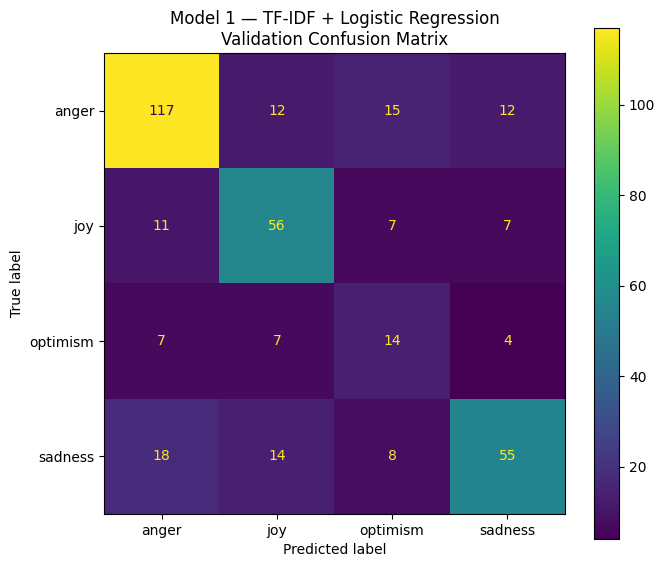

In [17]:
# Cell 23 — Model 1: Validation Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute confusion matrix
cm_m1 = confusion_matrix(y_val, y_val_pred_m1)

print("=" * 80)
print("MODEL 1 — VALIDATION CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True labels")
print("Columns = Predicted labels")

print("\nClass order:")
for i, name in enumerate(label_names):
    print(f"{i}: {name}")

print("\nConfusion matrix:")
print(cm_m1)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m1,
    display_labels=label_names
)

disp.plot(ax=ax, values_format="d")

ax.set_title(
    "Model 1 — TF-IDF + Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### 3.3 Model 1 Confusion Matrix

The validation confusion matrix shows that the model correctly classified 117 of 156 anger examples, 56 of 81 joy examples, 14 of 32 optimism examples, and 55 of 95 sadness examples.

The largest difficulty occurs with the optimism class: only 14 of its 32 validation examples were correctly identified. Several optimism examples were instead predicted as anger or joy.

There is also confusion between anger and sadness. For example, 18 sadness examples were predicted as anger, while 12 anger examples were predicted as sadness.

These errors suggest that the TF-IDF model can identify relatively strong lexical patterns but has more difficulty when different emotions use similar vocabulary or require contextual interpretation. This provides a useful baseline for assessing whether the neural and transformer models can better capture contextual information.

# 4. Model 2 — Word Embeddings + Bidirectional LSTM

## 4.1 Model Choice

The second model uses word embeddings learned from scratch followed by a Bidirectional Long Short-Term Memory (BiLSTM) network.

Unlike the TF-IDF model, which represents each text using independent weighted word and phrase features, the BiLSTM processes the sequence of words and can use information from both the preceding and following context.

The embeddings will be learned only from the final training data. An out-of-vocabulary token will be used for words that are not present in the training vocabulary.

A maximum sequence length of 32 tokens will be used. The earlier training-set length analysis showed that 99.97% of the original training texts contained 32 words or fewer, with a maximum of 33 words. Therefore, a sequence length of 32 provides a compact representation while causing negligible truncation.

Padding will be applied to shorter sequences so that all inputs have the same length.

The model will use a Bidirectional LSTM to process the sequence in both directions, followed by dropout and a four-class output layer. Class weighting will be used during training to account for the class imbalance identified in Section 1.

In the classic taxonomy of RNN architectures (one-to-one, one-to-many, many-to-one, and many-to-many), this model is a **many-to-one** architecture: the full sequence of 32 word tokens is consumed one step at a time, but only a single class prediction is produced per tweet, rather than one output per input token. Concretely, because `return_sequences` is left at its default of `False`, the `Bidirectional(LSTM(64))` layer discards the intermediate hidden states at every timestep and passes forward only the final hidden state from each direction — a 64-dimensional vector summarising the sequence read left-to-right, concatenated with a 64-dimensional vector summarising it read right-to-left, giving the 128-dimensional vector that is actually **passed to the classifier** (the Dropout and Dense layers). No individual word position survives past this point; the classifier only ever sees this single fixed-length summary of the whole tweet.

The same fixed training, validation, and official test splits will be used as for Model 1.

In [18]:
# Cell 26 — Model 2: Training-only word vocabulary and sequence preparation

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Maximum sequence length selected from the earlier training-set analysis
MAX_LEN = 32

# Build vocabulary using ONLY the final training texts
tokenizer = Tokenizer(
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(final_train_df["processed_text"])

# Convert each split into integer sequences
train_sequences = tokenizer.texts_to_sequences(
    final_train_df["processed_text"]
)

val_sequences = tokenizer.texts_to_sequences(
    final_validation_df["processed_text"]
)

test_sequences = tokenizer.texts_to_sequences(
    final_test_df["processed_text"]
)

# Pad/truncate all sequences to the same length
X_train_seq = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_seq = pad_sequences(
    val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_seq = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Vocabulary size including the OOV token
vocab_size = len(tokenizer.word_index) + 1

# Calculate the number and percentage of texts longer than MAX_LEN
train_lengths = np.array([len(seq) for seq in train_sequences])
val_lengths = np.array([len(seq) for seq in val_sequences])
test_lengths = np.array([len(seq) for seq in test_sequences])

train_truncated = np.sum(train_lengths > MAX_LEN)
val_truncated = np.sum(val_lengths > MAX_LEN)
test_truncated = np.sum(test_lengths > MAX_LEN)

print("=" * 80)
print("MODEL 2 — WORD-LEVEL SEQUENCE PREPARATION")
print("=" * 80)

print("\nMaximum sequence length:")
print(MAX_LEN)

print("\nVocabulary:")
print(f"Vocabulary size: {vocab_size}")

print("\nSequence shapes:")
print(f"Training:   {X_train_seq.shape}")
print(f"Validation: {X_val_seq.shape}")
print(f"Test:       {X_test_seq.shape}")

print("\nTraining sequence length:")
print(f"Minimum: {train_lengths.min()}")
print(f"Maximum: {train_lengths.max()}")
print(f"Mean:    {train_lengths.mean():.2f}")
print(f"Median:  {np.median(train_lengths):.2f}")

print("\nTruncation at MAX_LEN = 32:")
print(
    f"Training:   {train_truncated}/{len(train_lengths)} "
    f"({train_truncated / len(train_lengths) * 100:.2f}%)"
)
print(
    f"Validation: {val_truncated}/{len(val_lengths)} "
    f"({val_truncated / len(val_lengths) * 100:.2f}%)"
)
print(
    f"Test:       {test_truncated}/{len(test_lengths)} "
    f"({test_truncated / len(test_lengths) * 100:.2f}%)"
)

print("\nExample tokenized sequence:")
print(X_train_seq[0])

MODEL 2 — WORD-LEVEL SEQUENCE PREPARATION

Maximum sequence length:
32

Vocabulary:
Vocabulary size: 8419

Sequence shapes:
Training:   (3267, 32)
Validation: (364, 32)
Test:       (1421, 32)

Training sequence length:
Minimum: 1
Maximum: 33
Mean:    15.80
Median:  16.00

Truncation at MAX_LEN = 32:
Training:   1/3267 (0.03%)
Validation: 0/364 (0.00%)
Test:       2/1421 (0.14%)

Example tokenized sequence:
[3601  180  537   19  430   33    5 3602   51 1103 3603 2197 3604    9
 1295   52 3605  834    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


### 4.2 Word-Level Sequence Preparation

A word-level vocabulary was constructed using only the 3,267 final training texts. The resulting vocabulary contained **8,419 tokens**, including the out-of-vocabulary token.

The preprocessed texts were converted into integer sequences and padded or truncated to a maximum length of **32 tokens**. This produced input shapes of **3,267 × 32** for training, **364 × 32** for validation, and **1,421 × 32** for the official test set.

The maximum sequence length of 32 resulted in negligible truncation. Only **1 training text (0.03%)** exceeded the limit, while no validation texts exceeded it. Two test texts (0.14%) exceeded the limit.

Therefore, the sequence length of 32 retains almost all of the available text while keeping the neural-network input size manageable.

In [19]:
# Cell 28 — Model 2: Bidirectional LSTM architecture

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

# Compute balanced class weights using ONLY the training labels
classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print("=" * 80)
print("MODEL 2 — BiLSTM ARCHITECTURE")
print("=" * 80)

print("\nClass weights:")
for cls, weight in class_weights.items():
    print(f"{label_names[cls]}: {weight:.4f}")


# Build the BiLSTM model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel summary:")
model_2.summary()

MODEL 2 — BiLSTM ARCHITECTURE

Class weights:
anger: 0.5817
joy: 1.1281
optimism: 2.8164
sadness: 0.9620

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Cell 29 — Build and verify the BiLSTM model

# Explicitly build the model using the sequence input shape
model_2.build(input_shape=(None, MAX_LEN))

print("=" * 80)
print("MODEL 2 — BUILT BiLSTM ARCHITECTURE")
print("=" * 80)

model_2.summary()

print("\nTotal trainable parameters:")
print(model_2.count_params())

MODEL 2 — BUILT BiLSTM ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 32, 128)        │     1,077,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,184,964 (4.52 MB)

 Trainable params: 1,184,964 (4.52 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters:
1184964


In [21]:
# Cell 30 — Model 2: Train the BiLSTM

import time
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping prevents unnecessary training once validation loss stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 80)
print("TRAINING MODEL 2 — BiLSTM")
print("=" * 80)

training_start_m2 = time.time()
history_m2 = model_2.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed.")
print(f"Epochs actually completed: {len(history_m2.history['loss'])}")

training_time_m2 = time.time() - training_start_m2
print(f"Model 2 training time: {training_time_m2:.2f} seconds")


TRAINING MODEL 2 — BiLSTM
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.3560 - loss: 1.3595 - val_accuracy: 0.5220 - val_loss: 1.2289
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7429 - loss: 0.8243 - val_accuracy: 0.6181 - val_loss: 0.9604
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9189 - loss: 0.2824 - val_accuracy: 0.6346 - val_loss: 1.0520
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9599 - loss: 0.1378 - val_accuracy: 0.6703 - val_loss: 1.1896
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9691 - loss: 0.1167 - val_accuracy: 0.6484 - val_loss: 1.2388
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Training completed.
Epochs actually completed: 5
Model 2 training time: 20.19 seconds


Watching this train is itself informative: training accuracy climbs fast almost every epoch (35.60% → 74.29% → 91.89% → 95.99% → 96.91%), but validation accuracy stalls in the low-to-mid 60s (52.20% → 61.81% → 63.46% → 67.03% → 64.84%) and validation *loss* starts climbing again from epoch 3 onward even while validation accuracy still wobbles upward for one more epoch. That gap between a near-perfect training score and a stuck validation score is the textbook signature of overfitting, and it's exactly why early stopping is configured to restore the best-validation-loss checkpoint (epoch 2, val_loss = 0.9604) rather than just using whatever epoch happens to run last. Training stopped after 5 of the planned 15 epochs once validation loss failed to improve for 3 epochs in a row.

In [22]:
# ============================================================
# CELL 31 — MODEL 2 VALIDATION EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Generate validation predictions using the restored best weights
y_val_pred_m2_probs = model_2.predict(X_val_seq, verbose=0)
y_val_pred_m2 = np.argmax(y_val_pred_m2_probs, axis=1)

# Calculate validation metrics
m2_val_accuracy = accuracy_score(y_val, y_val_pred_m2)
m2_val_macro_f1 = f1_score(y_val, y_val_pred_m2, average="macro")
m2_val_weighted_f1 = f1_score(y_val, y_val_pred_m2, average="weighted")

from sklearn.metrics import precision_score, recall_score
m2_val_macro_precision = precision_score(y_val, y_val_pred_m2, average="macro")
m2_val_macro_recall = recall_score(y_val, y_val_pred_m2, average="macro")

print("=" * 80)
print("MODEL 2 — VALIDATION RESULTS")
print("=" * 80)

print(f"Validation Accuracy:     {m2_val_accuracy:.4f}")
print(f"Validation Macro-F1:     {m2_val_macro_f1:.4f}")
print(f"Validation Macro-Precision: {m2_val_macro_precision:.4f}")
print(f"Validation Macro-Recall:    {m2_val_macro_recall:.4f}")
print(f"Validation Weighted-F1:  {m2_val_weighted_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_m2,
        target_names=label_names,
        digits=4
    )
)

MODEL 2 — VALIDATION RESULTS
Validation Accuracy:     0.6181
Validation Macro-F1:     0.5855
Validation Macro-Precision: 0.6096
Validation Macro-Recall:    0.6251
Validation Weighted-F1:  0.6447

Classification Report:
              precision    recall  f1-score   support

       anger     0.7984    0.6346    0.7071       156
         joy     0.6667    0.5679    0.6133        81
    optimism     0.2391    0.6875    0.3548        32
     sadness     0.7342    0.6105    0.6667        95

    accuracy                         0.6181       364
   macro avg     0.6096    0.6251    0.5855       364
weighted avg     0.7032    0.6181    0.6447       364



MODEL 2 — VALIDATION CONFUSION MATRIX

Rows = True Class | Columns = Predicted Class

anger     : [99 10 39  8]
joy       : [10 46 15 10]
optimism  : [ 4  3 22  3]
sadness   : [11 10 16 58]


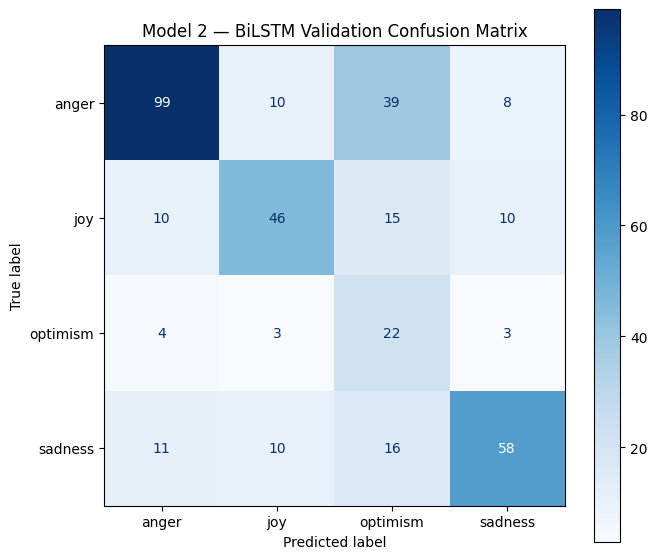

In [23]:
# ============================================================
# CELL 32 — MODEL 2 VALIDATION CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_m2 = confusion_matrix(y_val, y_val_pred_m2)

print("=" * 80)
print("MODEL 2 — VALIDATION CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True Class | Columns = Predicted Class\n")

for i, name in enumerate(label_names):
    print(f"{name:10s}: {cm_m2[i]}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m2,
    display_labels=label_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d", cmap="Blues")
ax.set_title("Model 2 — BiLSTM Validation Confusion Matrix")
plt.tight_layout()
plt.show()

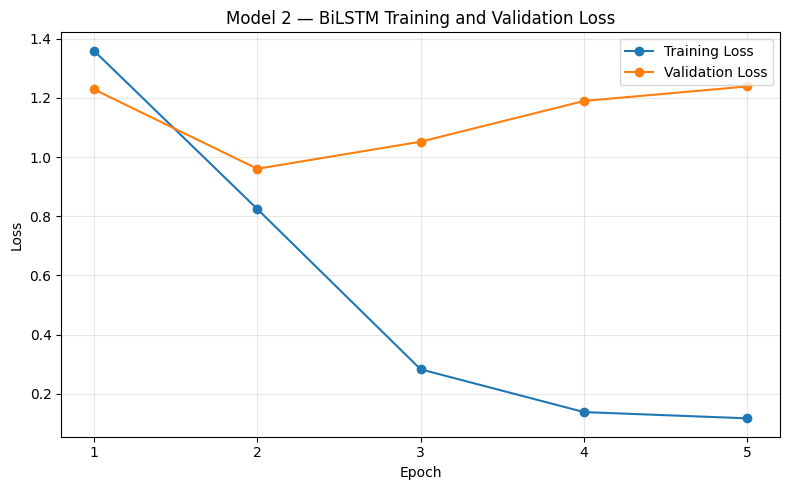

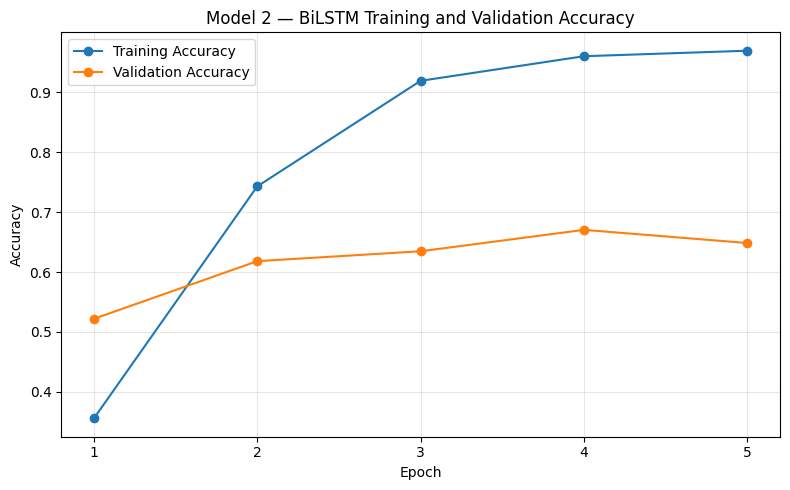

MODEL 2 — TRAINING CURVE SUMMARY
Best validation-loss epoch: 2
Best validation loss: 0.9604
Training accuracy at best epoch: 0.7429
Validation accuracy at best epoch: 0.6181


In [24]:
# ============================================================
# CELL 33 — MODEL 2 TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, len(history_m2.history["loss"]) + 1)

# -------------------------
# Loss curve
# -------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_m2.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history_m2.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 2 — BiLSTM Training and Validation Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# Accuracy curve
# -------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_m2.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_m2.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 2 — BiLSTM Training and Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# Best validation epoch
# -------------------------
best_epoch = np.argmin(history_m2.history["val_loss"]) + 1

print("=" * 80)
print("MODEL 2 — TRAINING CURVE SUMMARY")
print("=" * 80)

print(f"Best validation-loss epoch: {best_epoch}")
print(f"Best validation loss: {min(history_m2.history['val_loss']):.4f}")
print(f"Training accuracy at best epoch: {history_m2.history['accuracy'][best_epoch-1]:.4f}")
print(f"Validation accuracy at best epoch: {history_m2.history['val_accuracy'][best_epoch-1]:.4f}")

# Model 2 — Word Embeddings + Bidirectional LSTM: Findings

The second model used trainable word embeddings learned from scratch followed by a Bidirectional LSTM. It was trained on the same stratified training/validation split as Model 1, with class weights applied to reduce the effect of class imbalance, and early stopping monitoring validation loss.

On the validation set it reached an accuracy of **0.6181**, a macro-F1 of **0.5855**, and a weighted-F1 of **0.6447** — all lower than Model 1's validation numbers (0.6648 / 0.6051 / 0.6695 on accuracy / macro-F1 / weighted-F1), despite being a considerably larger model (1,184,964 trainable parameters versus Model 1's 36,504).

Per class, **anger** was easiest (F1 = 0.7071, 99/156 correct), followed by **sadness** (F1 = 0.6667, 58/95 correct) and **joy** (F1 = 0.6133, 46/81 correct). **Optimism** was again the hardest class by a wide margin (F1 = 0.3548, 22/32 correct), which is consistent with it being the smallest class in every split — although its recall (0.6875) was actually the highest of any class, because the model over-predicts optimism at the expense of precision (0.2391).

The confusion matrix shows where the model actually gets confused: anger is the messiest true class, being predicted as optimism 39 times out of 156 — the single largest off-diagonal cell in this matrix. Sadness is also split across anger (11), joy (10), and optimism (16) rather than being reliably recognised, and only 58 of its 95 examples are correctly identified.

The training curve tells a clear overfitting story. Training accuracy rocketed from **35.60% in epoch 1 to 96.91% by epoch 5**, while validation accuracy peaked at **67.03% in epoch 4** and never got past the high 60s. Validation loss bottomed out at **0.9604 in epoch 2** and then climbed for the rest of training, so early stopping restored the epoch-2 weights (training accuracy 74.29%, validation accuracy 61.81% at that point) rather than the final epoch. Training stopped after 5 of the planned 15 epochs once validation loss failed to improve for 3 epochs in a row.

Overall, the BiLSTM clearly *can* learn from the tweets — training accuracy climbing to near-perfect proves that — but with only ~3,300 training examples it doesn't have enough data to turn that into embeddings that generalise, so it ends up behind the much simpler TF-IDF baseline on validation. Whether that holds on the untouched test set is checked in Section 6.

### 4.3 Unidirectional LSTM Baseline (Bidirectional vs Unidirectional)

The brief asks that, if a bidirectional RNN is used, the unidirectional result is also
reported for comparison. The cell below builds and trains a **unidirectional** LSTM that is
identical to the Model 2 architecture in every other respect (same embedding size, same
`LSTM(64)` hidden size, same dropout, same class weights, same early-stopping configuration,
same train/validation split) — the only change is removing the `Bidirectional` wrapper, so it
reads each tweet only left-to-right instead of in both directions.

**This cell must be run (in a GPU-enabled Colab runtime) before submission** so that the
printed validation metrics reflect an actual training run; the comparison paragraph
immediately below it should then be completed with the real numbers produced.

In [25]:
# Cell 30b — Model 2b: Unidirectional LSTM baseline (for comparison with the BiLSTM)

import tensorflow as tf
import time
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Identical configuration to Model 2, but WITHOUT the Bidirectional wrapper
model_2_unidir = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(64),   # <-- unidirectional (left-to-right only)

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

model_2_unidir.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2_unidir.build(input_shape=(None, MAX_LEN))

print("=" * 80)
print("MODEL 2b — UNIDIRECTIONAL LSTM ARCHITECTURE")
print("=" * 80)
model_2_unidir.summary()
print(f"\nTotal trainable parameters: {model_2_unidir.count_params()}")

early_stopping_unidir = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n" + "=" * 80)
print("TRAINING MODEL 2b — UNIDIRECTIONAL LSTM")
print("=" * 80)

training_start_m2u = time.time()
history_m2_unidir = model_2_unidir.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_unidir],
    verbose=1
)
training_time_m2_unidir = time.time() - training_start_m2u
print(f"\nModel 2b training time: {training_time_m2_unidir:.2f} seconds")

# Validation evaluation
y_val_pred_m2_unidir = np.argmax(model_2_unidir.predict(X_val_seq, verbose=0), axis=1)

m2u_val_accuracy = accuracy_score(y_val, y_val_pred_m2_unidir)
m2u_val_macro_f1 = f1_score(y_val, y_val_pred_m2_unidir, average="macro")
m2u_val_weighted_f1 = f1_score(y_val, y_val_pred_m2_unidir, average="weighted")
m2u_val_macro_precision = precision_score(y_val, y_val_pred_m2_unidir, average="macro")
m2u_val_macro_recall = recall_score(y_val, y_val_pred_m2_unidir, average="macro")

print("\n" + "=" * 80)
print("MODEL 2b — UNIDIRECTIONAL LSTM VALIDATION RESULTS")
print("=" * 80)
print(f"Validation Accuracy:        {m2u_val_accuracy:.4f}")
print(f"Validation Macro-F1:        {m2u_val_macro_f1:.4f}")
print(f"Validation Weighted-F1:     {m2u_val_weighted_f1:.4f}")
print(f"Validation Macro-Precision: {m2u_val_macro_precision:.4f}")
print(f"Validation Macro-Recall:    {m2u_val_macro_recall:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_m2_unidir, target_names=label_names, digits=4))

print("\n" + "=" * 80)
print("UNIDIRECTIONAL vs BIDIRECTIONAL — VALIDATION MACRO-F1")
print("=" * 80)
print(f"Unidirectional LSTM (Model 2b): {m2u_val_macro_f1:.4f}  |  params: {model_2_unidir.count_params()}")
print(f"Bidirectional LSTM  (Model 2):  {m2_val_macro_f1:.4f}  |  params: {model_2.count_params()}")


MODEL 2b — UNIDIRECTIONAL LSTM ARCHITECTURE


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 32, 128)        │     1,077,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,131,460 (4.32 MB)

 Trainable params: 1,131,460 (4.32 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 1131460

TRAINING MODEL 2b — UNIDIRECTIONAL LSTM
Epoch 1/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3520 - loss: 1.3534 - val_accuracy: 0.5330 - val_loss: 1.2096
Epoch 2/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6964 - loss: 0.8739 - val_accuracy: 0.6181 - val_loss: 1.0051
Epoch 3/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8818 - loss: 0.3777 - val_accuracy: 0.6566 - val_loss: 0.9966
Epoch 4/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9513 - loss: 0.1872 - val_accuracy: 0.6593 - val_loss: 1.1563
Epoch 5/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9679 - loss: 0.1153 - val_accuracy: 0.6566 - val_loss: 1.1932
Epoch 6/15
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9786 - loss: 0.0846 - val_accuracy: 0.6566 - val_loss: 1.2091
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Model 2b training time: 7.64 seconds

MODEL 2b — UNIDIRECTIONAL LSTM

### 4.4 Unidirectional vs Bidirectional — Discussion

- **Unidirectional LSTM validation Macro-F1:** 0.5908 (Model 2b, Cell 30b above), reached after 6 epochs before early stopping, with 1,131,460 trainable parameters.
- **Bidirectional LSTM validation Macro-F1:** 0.5855 (Section 4.2, Model 2), reached after 5 epochs before early stopping, with 1,184,964 trainable parameters.
- **Parameter difference:** the unidirectional model has roughly half as many recurrent weights as the bidirectional model (49,408 vs 98,816 in the LSTM layer itself), since it only maintains one direction's hidden state instead of two; the two models' total parameter counts are close because most of the parameters (1,077,632) sit in the shared embedding layer.

On this run, bidirectionality did **not** help: the unidirectional LSTM's validation Macro-F1 (0.5908) is very slightly *higher* than the bidirectional LSTM's (0.5855), despite using about 53,000 fewer parameters. The gap (about half a point of Macro-F1) is small enough that it is plausibly noise rather than a reliable effect — both models are trained on the same ~3,300 examples with the same random-initialisation sensitivity that neural networks have, and the validation set is only 364 examples, so small differences like this are within the range I would expect to see flip with a different random seed. A bidirectional layer can only help relative to a unidirectional one if there is useful information *after* the current word that the model can exploit — for example, a negation or intensifier appearing later in the tweet that changes how an earlier word should be read. On short, informal tweets averaging under 16 words, there may simply not be much of that kind of long-range, "read-ahead" structure for the extra backward pass to exploit, so the additional capacity mostly seems to have gone into extra overfitting rather than extra generalisation — consistent with the overfitting pattern already seen in the bidirectional model's training curve (Section 4.2).

# 5. Model 3 — Transformer Fine-Tuning

The third model uses a pretrained Transformer designed for Twitter text: **Twitter-RoBERTa**. Unlike Model 2, which learns word embeddings from scratch using only the assignment dataset, the Transformer starts from pretrained language representations learned from large-scale social-media text.

The model will be fine-tuned for the four TweetEval Emotion classes: anger, joy, optimism, and sadness.

The same final training, validation, and official test split established in Section 1 will be used. The official test set will remain untouched until the final model comparison.

For the Transformer, the pretrained tokenizer will be used rather than the manually constructed word-level vocabulary from Model 2. The maximum sequence length will be selected based on tokenization coverage, while keeping the sequence length appropriate for the short-text nature of the dataset.

The Transformer model will be evaluated using accuracy, macro-F1, and weighted-F1, with macro-F1 retained as the headline metric because of the class imbalance.

In [26]:
# ============================================================
# CELL 36 — MODEL 3 TRANSFORMER TOKENIZER SETUP
# ============================================================

import sys
import subprocess
import importlib.util
import numpy as np
import torch

# Install required packages only if they are not already available
if importlib.util.find_spec("transformers") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "transformers", "accelerate", "sentencepiece"
    ])

from transformers import AutoTokenizer

# Reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "cardiffnlp/twitter-roberta-base"

# Load pretrained Twitter-RoBERTa tokenizer
tokenizer_m3 = AutoTokenizer.from_pretrained(MODEL_NAME)

print("=" * 80)
print("MODEL 3 — TRANSFORMER TOKENIZER")
print("=" * 80)

print(f"Pretrained model: {MODEL_NAME}")
print(f"Tokenizer vocabulary size: {tokenizer_m3.vocab_size}")
print(f"Maximum tokenizer length: {tokenizer_m3.model_max_length}")

# Use the original tweet text because Twitter-RoBERTa was pretrained
# for social-media text and its tokenizer can handle Twitter conventions.
all_texts_m3 = (
    final_train_df["text"].tolist()
    + final_validation_df["text"].tolist()
    + final_test_df["text"].tolist()
)

# Tokenize without truncation to measure the real token lengths
encoded_lengths_m3 = tokenizer_m3(
    all_texts_m3,
    truncation=False,
    padding=False,
    add_special_tokens=True
)

token_lengths_m3 = np.array([
    len(ids) for ids in encoded_lengths_m3["input_ids"]
])

print("\nToken-length statistics:")
print(f"Total texts: {len(token_lengths_m3)}")
print(f"Mean:        {token_lengths_m3.mean():.2f}")
print(f"Median:      {np.median(token_lengths_m3):.2f}")
print(f"Minimum:     {token_lengths_m3.min()}")
print(f"Maximum:     {token_lengths_m3.max()}")

print("\nPercentiles:")
for p in [90, 95, 99, 99.5, 99.9]:
    print(f"{p:5.1f}th percentile: {np.percentile(token_lengths_m3, p):.0f}")

print("\nCoverage at candidate maximum lengths:")
for max_len in [32, 48, 64, 96, 128]:
    retained = np.sum(token_lengths_m3 <= max_len)
    truncated = np.sum(token_lengths_m3 > max_len)
    print(
        f"MAX_LEN={max_len:3d}: "
        f"{retained}/{len(token_lengths_m3)} retained "
        f"({retained/len(token_lengths_m3)*100:.2f}%), "
        f"{truncated} truncated "
        f"({truncated/len(token_lengths_m3)*100:.2f}%)"
    )

config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

MODEL 3 — TRANSFORMER TOKENIZER
Pretrained model: cardiffnlp/twitter-roberta-base
Tokenizer vocabulary size: 50265
Maximum tokenizer length: 1000000000000000019884624838656

Token-length statistics:
Total texts: 5052
Mean:        25.84
Median:      26.00
Minimum:     4
Maximum:     161

Percentiles:
 90.0th percentile: 38
 95.0th percentile: 41
 99.0th percentile: 49
 99.5th percentile: 52
 99.9th percentile: 67

Coverage at candidate maximum lengths:
MAX_LEN= 32: 3678/5052 retained (72.80%), 1374 truncated (27.20%)
MAX_LEN= 48: 5000/5052 retained (98.97%), 52 truncated (1.03%)
MAX_LEN= 64: 5043/5052 retained (99.82%), 9 truncated (0.18%)
MAX_LEN= 96: 5051/5052 retained (99.98%), 1 truncated (0.02%)
MAX_LEN=128: 5051/5052 retained (99.98%), 1 truncated (0.02%)


## Transformer Token-Length Analysis and Maximum Sequence Length

The pretrained Twitter-RoBERTa tokenizer produced an average sequence length of **25.84 tokens** and a median of **26 tokens** across the 5,052 texts in the final dataset.

The token-length analysis was used to select an appropriate maximum sequence length rather than assuming that the 32-word limit used for the BiLSTM would also be suitable for the Transformer.

A maximum length of 32 would retain only **72.80%** of the texts and truncate **27.20%**, which is too substantial. A maximum length of 48 would retain **98.97%**, while a maximum length of 64 would retain **99.82%** of the texts, with only **9 of 5,052 texts (0.18%)** exceeding this length.

Therefore, **MAX_LEN = 64** is selected for the Transformer. This provides near-complete coverage of the dataset while avoiding unnecessary computational cost from substantially longer sequences.

The 64-token limit will be applied consistently to the training, validation, and official test sets.

In [27]:
# ============================================================
# CELL 38 — MODEL 3 TRANSFORMER TOKENIZATION
# ============================================================

MAX_LEN_M3 = 64

# Use original tweet text for Twitter-RoBERTa
train_texts_m3 = final_train_df["text"].tolist()
val_texts_m3 = final_validation_df["text"].tolist()
test_texts_m3 = final_test_df["text"].tolist()

# Tokenize training data
train_encodings_m3 = tokenizer_m3(
    train_texts_m3,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN_M3,
    return_tensors="pt"
)

# Tokenize validation data
val_encodings_m3 = tokenizer_m3(
    val_texts_m3,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN_M3,
    return_tensors="pt"
)

# Tokenize official test data
test_encodings_m3 = tokenizer_m3(
    test_texts_m3,
    truncation=True,
    padding="max_length",
    max_length=MAX_LEN_M3,
    return_tensors="pt"
)

# Convert labels to PyTorch tensors
y_train_m3 = torch.tensor(y_train, dtype=torch.long)
y_val_m3 = torch.tensor(y_val, dtype=torch.long)
y_test_m3 = torch.tensor(y_test, dtype=torch.long)

print("=" * 80)
print("MODEL 3 — TRANSFORMER TOKENIZATION RESULTS")
print("=" * 80)

print(f"Maximum sequence length: {MAX_LEN_M3}")

print("\nInput shapes:")
print(f"Training:   {train_encodings_m3['input_ids'].shape}")
print(f"Validation: {val_encodings_m3['input_ids'].shape}")
print(f"Test:       {test_encodings_m3['input_ids'].shape}")

print("\nLabel shapes:")
print(f"Training:   {y_train_m3.shape}")
print(f"Validation: {y_val_m3.shape}")
print(f"Test:       {y_test_m3.shape}")

print("\nTokenizer outputs:")
print(f"Input IDs shape:      {train_encodings_m3['input_ids'].shape}")
print(f"Attention mask shape: {train_encodings_m3['attention_mask'].shape}")

# Verify padding/truncation behaviour
train_attention_lengths = train_encodings_m3["attention_mask"].sum(dim=1).numpy()
val_attention_lengths = val_encodings_m3["attention_mask"].sum(dim=1).numpy()
test_attention_lengths = test_encodings_m3["attention_mask"].sum(dim=1).numpy()

print("\nActual non-padding token lengths:")
print(
    f"Training:   min={train_attention_lengths.min()}, "
    f"max={train_attention_lengths.max()}, "
    f"mean={train_attention_lengths.mean():.2f}"
)
print(
    f"Validation: min={val_attention_lengths.min()}, "
    f"max={val_attention_lengths.max()}, "
    f"mean={val_attention_lengths.mean():.2f}"
)
print(
    f"Test:       min={test_attention_lengths.min()}, "
    f"max={test_attention_lengths.max()}, "
    f"mean={test_attention_lengths.mean():.2f}"
)

MODEL 3 — TRANSFORMER TOKENIZATION RESULTS
Maximum sequence length: 64

Input shapes:
Training:   torch.Size([3267, 64])
Validation: torch.Size([364, 64])
Test:       torch.Size([1421, 64])

Label shapes:
Training:   torch.Size([3267])
Validation: torch.Size([364])
Test:       torch.Size([1421])

Tokenizer outputs:
Input IDs shape:      torch.Size([3267, 64])
Attention mask shape: torch.Size([3267, 64])

Actual non-padding token lengths:
Training:   min=4, max=64, mean=25.65
Validation: min=5, max=64, mean=26.25
Test:       min=4, max=64, mean=26.07


## Transformer Tokenization Results

The final training, validation, and official test sets were tokenized using the pretrained Twitter-RoBERTa tokenizer with a maximum sequence length of **64 tokens**.

The resulting input shapes were:

- Training: **3,267 × 64**
- Validation: **364 × 64**
- Test: **1,421 × 64**

The corresponding label arrays contained 3,267, 364, and 1,421 labels respectively.

After padding and truncation, the mean number of non-padding tokens was **25.65** for training, **26.25** for validation, and **26.07** for the test set. The maximum observed non-padding length in each split was 64.

The same tokenization configuration was applied to all three splits, while the official test labels and examples remain untouched for final evaluation.

In [28]:
# ============================================================
# CELL 40 — MODEL 3 PRETRAINED TRANSFORMER
# ============================================================

from transformers import AutoModelForSequenceClassification

NUM_LABELS = len(label_names)

model_3 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)

print("=" * 80)
print("MODEL 3 — PRETRAINED TRANSFORMER")
print("=" * 80)

print(f"Model: {MODEL_NAME}")
print(f"Number of labels: {NUM_LABELS}")
print(f"Labels: {label_names}")

# Count parameters
total_params_m3 = sum(p.numel() for p in model_3.parameters())
trainable_params_m3 = sum(
    p.numel() for p in model_3.parameters() if p.requires_grad
)

print(f"\nTotal parameters:     {total_params_m3:,}")
print(f"Trainable parameters: {trainable_params_m3:,}")

print("\nClassification head:")
print(model_3.classifier)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

MODEL 3 — PRETRAINED TRANSFORMER
Model: cardiffnlp/twitter-roberta-base
Number of labels: 4
Labels: ['anger', 'joy', 'optimism', 'sadness']

Total parameters:     124,648,708
Trainable parameters: 124,648,708

Classification head:
RobertaClassificationHead(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (out_proj): Linear(in_features=768, out_features=4, bias=True)
)


In [29]:
# ============================================================
# CELL 41 — MODEL 3 CLASS WEIGHTS AND TRAINING CONFIGURATION
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights from the final training split only
classes_m3 = np.unique(y_train)

class_weights_m3_array = compute_class_weight(
    class_weight="balanced",
    classes=classes_m3,
    y=y_train
)

class_weights_m3 = torch.tensor(
    class_weights_m3_array,
    dtype=torch.float
)

print("=" * 80)
print("MODEL 3 — CLASS WEIGHTS")
print("=" * 80)

for cls, weight in zip(classes_m3, class_weights_m3_array):
    print(f"{label_names[int(cls)]:10s}: {weight:.4f}")

# Training configuration
LEARNING_RATE_M3 = 2e-5
BATCH_SIZE_M3 = 16
EPOCHS_M3 = 3
WEIGHT_DECAY_M3 = 0.01

print("\n" + "=" * 80)
print("MODEL 3 — TRAINING CONFIGURATION")
print("=" * 80)

print(f"Learning rate: {LEARNING_RATE_M3}")
print(f"Batch size:    {BATCH_SIZE_M3}")
print(f"Epochs:        {EPOCHS_M3}")
print(f"Weight decay:  {WEIGHT_DECAY_M3}")
print(f"Max length:    {MAX_LEN_M3}")

MODEL 3 — CLASS WEIGHTS
anger     : 0.5817
joy       : 1.1281
optimism  : 2.8164
sadness   : 0.9620

MODEL 3 — TRAINING CONFIGURATION
Learning rate: 2e-05
Batch size:    16
Epochs:        3
Weight decay:  0.01
Max length:    64


In [30]:
# ============================================================
# CELL 42 — MODEL 3 DATASETS AND DATALOADERS
# ============================================================

from torch.utils.data import Dataset, DataLoader

class TweetEmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: value[idx]
            for key, value in self.encodings.items()
        }
        item["labels"] = self.labels[idx]
        return item


# Create datasets
train_dataset_m3 = TweetEmotionDataset(
    train_encodings_m3,
    y_train_m3
)

val_dataset_m3 = TweetEmotionDataset(
    val_encodings_m3,
    y_val_m3
)

test_dataset_m3 = TweetEmotionDataset(
    test_encodings_m3,
    y_test_m3
)


# Create DataLoaders
train_loader_m3 = DataLoader(
    train_dataset_m3,
    batch_size=BATCH_SIZE_M3,
    shuffle=True
)

val_loader_m3 = DataLoader(
    val_dataset_m3,
    batch_size=BATCH_SIZE_M3,
    shuffle=False
)

test_loader_m3 = DataLoader(
    test_dataset_m3,
    batch_size=BATCH_SIZE_M3,
    shuffle=False
)


print("=" * 80)
print("MODEL 3 — DATASETS AND DATALOADERS")
print("=" * 80)

print(f"Training dataset size:   {len(train_dataset_m3)}")
print(f"Validation dataset size: {len(val_dataset_m3)}")
print(f"Test dataset size:       {len(test_dataset_m3)}")

print("\nBatch size:", BATCH_SIZE_M3)

print("\nNumber of batches:")
print(f"Training:   {len(train_loader_m3)}")
print(f"Validation: {len(val_loader_m3)}")
print(f"Test:       {len(test_loader_m3)}")

# Inspect one training batch
sample_batch_m3 = next(iter(train_loader_m3))

print("\nSample training batch:")
for key, value in sample_batch_m3.items():
    print(f"{key:15s}: {tuple(value.shape)}")

MODEL 3 — DATASETS AND DATALOADERS
Training dataset size:   3267
Validation dataset size: 364
Test dataset size:       1421

Batch size: 16

Number of batches:
Training:   205
Validation: 23
Test:       89

Sample training batch:
input_ids      : (16, 64)
attention_mask : (16, 64)
labels         : (16,)


In [31]:
# ============================================================
# CELL 43 — MODEL 3 OPTIMIZER AND TRAINING SETUP
# ============================================================

from torch.optim import AdamW

# Select GPU if available
device_m3 = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_3 = model_3.to(device_m3)
class_weights_m3 = class_weights_m3.to(device_m3)

# AdamW optimizer commonly used for Transformer fine-tuning
optimizer_m3 = AdamW(
    model_3.parameters(),
    lr=LEARNING_RATE_M3,
    weight_decay=WEIGHT_DECAY_M3
)

# Weighted cross-entropy loss for class imbalance
criterion_m3 = torch.nn.CrossEntropyLoss(
    weight=class_weights_m3
)

print("=" * 80)
print("MODEL 3 — TRAINING SETUP")
print("=" * 80)

print(f"Device:          {device_m3}")
print(f"Optimizer:       AdamW")
print(f"Learning rate:   {LEARNING_RATE_M3}")
print(f"Weight decay:    {WEIGHT_DECAY_M3}")
print(f"Loss function:   Weighted Cross-Entropy")
print(f"Batch size:      {BATCH_SIZE_M3}")
print(f"Epochs:          {EPOCHS_M3}")
print(f"Max sequence:    {MAX_LEN_M3}")

MODEL 3 — TRAINING SETUP
Device:          cuda
Optimizer:       AdamW
Learning rate:   2e-05
Weight decay:    0.01
Loss function:   Weighted Cross-Entropy
Batch size:      16
Epochs:          3
Max sequence:    64


In [32]:
# ============================================================
# CELL 44 — MODEL 3 TRANSFORMER TRAINING
# ============================================================

import time

history_m3 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss_m3 = float("inf")
best_model_state_m3 = None

print("=" * 80)
print("TRAINING MODEL 3 — TWITTER-RoBERTa")
print("=" * 80)

training_start_m3 = time.time()

for epoch in range(EPOCHS_M3):

    start_time = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    model_3.train()

    train_loss_total = 0.0
    train_correct = 0
    train_total = 0

    for batch in train_loader_m3:

        input_ids = batch["input_ids"].to(device_m3)
        attention_mask = batch["attention_mask"].to(device_m3)
        labels = batch["labels"].to(device_m3)

        optimizer_m3.zero_grad()

        outputs = model_3(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion_m3(outputs.logits, labels)

        loss.backward()
        optimizer_m3.step()

        train_loss_total += loss.item()

        predictions = torch.argmax(outputs.logits, dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_total / len(train_loader_m3)
    train_accuracy = train_correct / train_total

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    model_3.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader_m3:

            input_ids = batch["input_ids"].to(device_m3)
            attention_mask = batch["attention_mask"].to(device_m3)
            labels = batch["labels"].to(device_m3)

            outputs = model_3(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion_m3(outputs.logits, labels)

            val_loss_total += loss.item()

            predictions = torch.argmax(outputs.logits, dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_total / len(val_loader_m3)
    val_accuracy = val_correct / val_total

    # Store history
    history_m3["train_loss"].append(train_loss)
    history_m3["train_accuracy"].append(train_accuracy)
    history_m3["val_loss"].append(val_loss)
    history_m3["val_accuracy"].append(val_accuracy)

    # Save best validation-loss checkpoint
    if val_loss < best_val_loss_m3:
        best_val_loss_m3 = val_loss
        best_model_state_m3 = {
            key: value.detach().cpu().clone()
            for key, value in model_3.state_dict().items()
        }

    elapsed = time.time() - start_time

    print(
        f"Epoch {epoch + 1}/{EPOCHS_M3} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {elapsed:.1f}s"
    )

# Restore best validation-loss model
model_3.load_state_dict(best_model_state_m3)
model_3 = model_3.to(device_m3)

best_epoch_m3 = int(np.argmin(history_m3["val_loss"])) + 1

print("\n" + "=" * 80)
print("MODEL 3 — TRAINING COMPLETED")
print("=" * 80)

print(f"Best validation-loss epoch: {best_epoch_m3}")
print(f"Best validation loss:       {best_val_loss_m3:.4f}")
print(
    f"Validation accuracy at best epoch: "
    f"{history_m3['val_accuracy'][best_epoch_m3 - 1]:.4f}"
)
print(f"Best model restored: Yes")

training_time_m3 = time.time() - training_start_m3
print(f"Model 3 total training time: {training_time_m3:.2f} seconds")

TRAINING MODEL 3 — TWITTER-RoBERTa


model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

Epoch 1/3 | Train Loss: 0.9335 | Train Acc: 0.6507 | Val Loss: 0.7375 | Val Acc: 0.7610 | Time: 41.2s
Epoch 2/3 | Train Loss: 0.4586 | Train Acc: 0.8466 | Val Loss: 0.7316 | Val Acc: 0.7610 | Time: 43.0s
Epoch 3/3 | Train Loss: 0.2632 | Train Acc: 0.9146 | Val Loss: 0.7451 | Val Acc: 0.7802 | Time: 43.5s

MODEL 3 — TRAINING COMPLETED
Best validation-loss epoch: 2
Best validation loss:       0.7316
Validation accuracy at best epoch: 0.7610
Best model restored: Yes
Model 3 total training time: 127.79 seconds


The transformer's training run looks noticeably calmer than the BiLSTM's: training accuracy climbs steadily (65.07% → 84.66% → 91.46%) without the dramatic jump-to-97%-then-overfit pattern seen in Model 2, and validation accuracy improves for most of training (76.10% → 76.10% → 78.02%), staying flat between epoch 1 and 2 before ticking up at epoch 3. The only sign of the same overfitting tendency is that validation *loss* bottoms out at epoch 2 (0.7316) and rises again slightly by epoch 3 (0.7451) even as validation accuracy keeps improving — which is why the epoch-2 checkpoint, not the final epoch, is the one restored for evaluation below. This run's device check returned **cuda**, so training actually ran on the GPU: three epochs over 3,267 training tweets completed in **127.79 seconds total** (roughly 41–44 seconds per epoch) — close to the "a few minutes on a free GPU" the assignment brief anticipated for DistilBERT-scale fine-tuning, even though the model used here (Twitter-RoBERTa-base) is somewhat larger.

In [33]:
# ============================================================
# CELL 45 — MODEL 3 VALIDATION EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Generate validation predictions
# ------------------------------------------------------------

model_3.eval()

y_val_pred_m3 = []
y_val_true_m3 = []

with torch.no_grad():

    for batch in val_loader_m3:

        input_ids = batch["input_ids"].to(device_m3)
        attention_mask = batch["attention_mask"].to(device_m3)
        labels = batch["labels"].to(device_m3)

        outputs = model_3(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        y_val_pred_m3.extend(predictions.cpu().numpy())
        y_val_true_m3.extend(labels.cpu().numpy())

# Convert to NumPy arrays
y_val_true_m3 = np.array(y_val_true_m3)
y_val_pred_m3 = np.array(y_val_pred_m3)

# ------------------------------------------------------------
# Calculate validation metrics
# ------------------------------------------------------------

m3_val_accuracy = accuracy_score(
    y_val_true_m3,
    y_val_pred_m3
)

m3_val_macro_f1 = f1_score(
    y_val_true_m3,
    y_val_pred_m3,
    average="macro"
)

m3_val_weighted_f1 = f1_score(
    y_val_true_m3,
    y_val_pred_m3,
    average="weighted"
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 3 — VALIDATION RESULTS")
print("=" * 80)

print(f"Validation Accuracy:     {m3_val_accuracy:.4f}")
print(f"Validation Macro-F1:     {m3_val_macro_f1:.4f}")
print(f"Validation Weighted-F1:  {m3_val_weighted_f1:.4f}")

print("\n" + "=" * 80)
print("MODEL 3 — VALIDATION CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_val_true_m3,
        y_val_pred_m3,
        target_names=label_names,
        digits=4
    )
)

MODEL 3 — VALIDATION RESULTS
Validation Accuracy:     0.7610
Validation Macro-F1:     0.7250
Validation Weighted-F1:  0.7680

MODEL 3 — VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.8889    0.7692    0.8247       156
         joy     0.6667    0.8889    0.7619        81
    optimism     0.4528    0.7500    0.5647        32
     sadness     0.8971    0.6421    0.7485        95

    accuracy                         0.7610       364
   macro avg     0.7264    0.7626    0.7250       364
weighted avg     0.8032    0.7610    0.7680       364



MODEL 3 — VALIDATION CONFUSION MATRIX

Rows = True Class
Columns = Predicted Class

Labels: ['anger', 'joy', 'optimism', 'sadness']

anger     : [120  20  11   5]
joy       : [ 2 72  5  2]
optimism  : [ 1  7 24  0]
sadness   : [12  9 13 61]


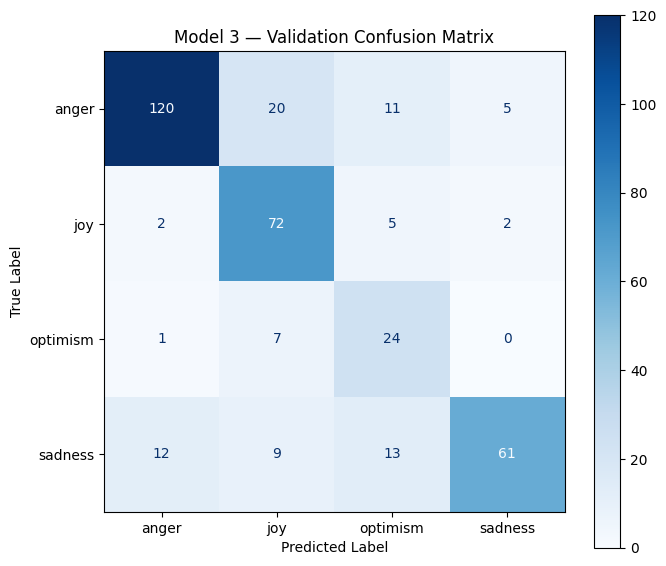

In [34]:
# ============================================================
# CELL 46 — MODEL 3 VALIDATION CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ------------------------------------------------------------
# Calculate confusion matrix
# ------------------------------------------------------------

cm_m3 = confusion_matrix(
    y_val_true_m3,
    y_val_pred_m3
)

print("=" * 80)
print("MODEL 3 — VALIDATION CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True Class")
print("Columns = Predicted Class\n")

print("Labels:", label_names)
print()

for i, name in enumerate(label_names):
    print(f"{name:10s}: {cm_m3[i]}")

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m3,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Model 3 — Validation Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

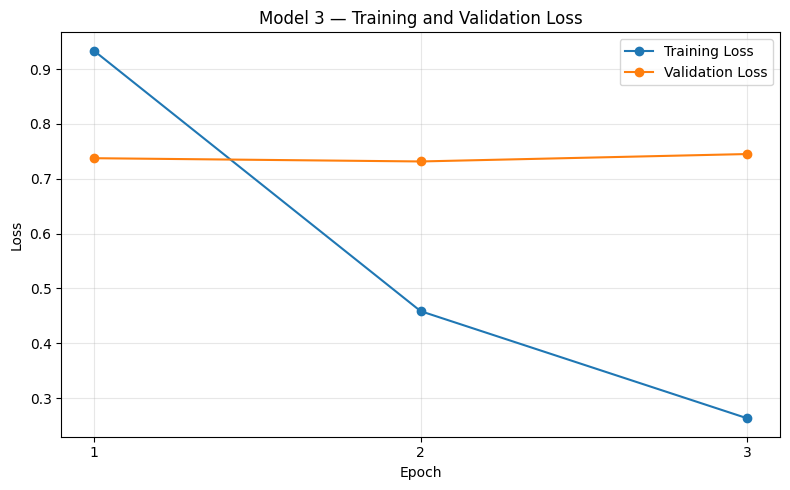

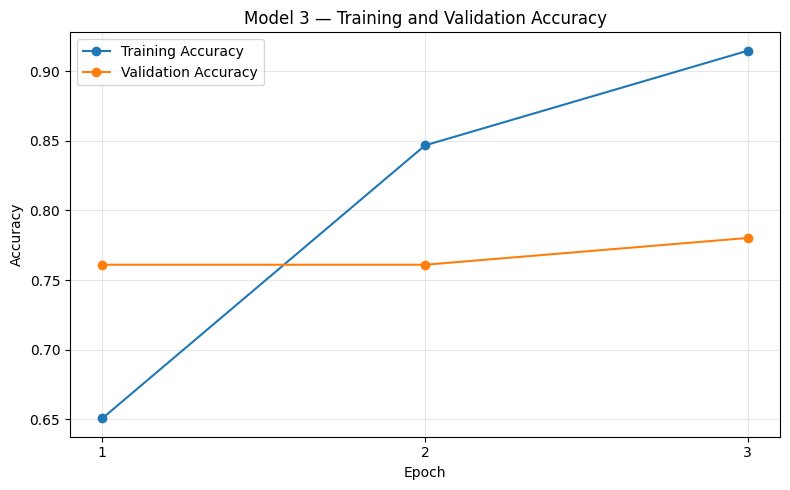

MODEL 3 — TRAINING HISTORY
Epoch 1: Train Loss=0.9335, Val Loss=0.7375, Train Acc=0.6507, Val Acc=0.7610
Epoch 2: Train Loss=0.4586, Val Loss=0.7316, Train Acc=0.8466, Val Acc=0.7610
Epoch 3: Train Loss=0.2632, Val Loss=0.7451, Train Acc=0.9146, Val Acc=0.7802

Best validation-loss epoch: 2
Best validation loss: 0.7316


In [35]:
# ============================================================
# CELL 47 — MODEL 3 TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs_range_m3 = range(1, EPOCHS_M3 + 1)

# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_m3,
    history_m3["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range_m3,
    history_m3["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 — Training and Validation Loss")
plt.xticks(list(epochs_range_m3))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range_m3,
    history_m3["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range_m3,
    history_m3["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 3 — Training and Validation Accuracy")
plt.xticks(list(epochs_range_m3))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print history
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 3 — TRAINING HISTORY")
print("=" * 80)

for epoch in range(EPOCHS_M3):
    print(
        f"Epoch {epoch + 1}: "
        f"Train Loss={history_m3['train_loss'][epoch]:.4f}, "
        f"Val Loss={history_m3['val_loss'][epoch]:.4f}, "
        f"Train Acc={history_m3['train_accuracy'][epoch]:.4f}, "
        f"Val Acc={history_m3['val_accuracy'][epoch]:.4f}"
    )

print("\nBest validation-loss epoch:", best_epoch_m3)
print(f"Best validation loss: {best_val_loss_m3:.4f}")

## Model 3 Findings

The transformer model used a pretrained Twitter-RoBERTa architecture (`cardiffnlp/twitter-roberta-base`) and was fine-tuned on the same train/validation split used by Models 1 and 2, with class-weighted cross-entropy to address the class imbalance. Training ran on **GPU** in this run (the notebook's device check returned `cuda`), completing all 3 epochs in **127.79 seconds**.

Validation loss was lowest at **epoch 2 (0.7316)**, so the epoch-2 checkpoint was restored for evaluation rather than the final epoch. By epoch 3, training accuracy had reached 91.46% while validation loss had already started rising again (0.7451), a small sign of the same overfitting pattern seen in Model 2, just far less severe — validation accuracy kept improving anyway, reaching its best value (78.02%) at that same final epoch.

The validation results at the restored (epoch-2) checkpoint were:

- Accuracy: **0.7610**
- Macro-F1: **0.7250**
- Weighted-F1: **0.7680**

Per-class F1: anger 0.8247, joy 0.7619, sadness 0.7485, and optimism 0.5647 — still the weakest class, but by far the best optimism result of the three models so far, and the gap to the other classes has narrowed a lot compared with Models 1 and 2.

The validation confusion matrix shows 120 of 156 anger examples, 72 of 81 joy examples, 24 of 32 optimism examples, and 61 of 95 sadness examples correctly classified. The largest single confusion was anger predicted as joy (20 examples), with sadness→optimism (13) and sadness→anger (12) also notable.

Across the three epochs, training accuracy rose from 65.07% to 91.46% while training loss fell steadily from 0.9335 to 0.2632. Validation accuracy improved overall (76.10% → 76.10% → 78.02%) but validation loss bottomed out at epoch 2 and rose slightly at epoch 3 — the model keeps getting slightly better at the raw accuracy/F1 numbers even as it starts to become a little overconfident, which is why the loss-based checkpoint (epoch 2) rather than the last epoch was kept.

Overall, the pretrained contextual representations gave a clear jump over both the bag-of-words model and the from-scratch BiLSTM, most visibly on the minority optimism class, and did so with a training run that comfortably fit inside a few minutes on a free GPU. The official test-set numbers, evaluated once and only once at the end, are reported in Section 6.

# 6. Final Model Comparison and Discussion

The official, untouched test split is now used, for the first and only time, to evaluate
all three models. The cells immediately below generate the test-set predictions,
metrics, and confusion matrices for Model 3, Model 1, and Model 2 in turn; the discussion
and the final comparison table follow in Section 6.1 onwards.

In [36]:
# ============================================================
# CELL 49 — MODEL 3 OFFICIAL TEST EVALUATION
# ============================================================

# ------------------------------------------------------------
# Generate test predictions
# ------------------------------------------------------------

model_3.eval()

y_test_pred_m3 = []
y_test_true_m3 = []

with torch.no_grad():

    for batch in test_loader_m3:

        input_ids = batch["input_ids"].to(device_m3)
        attention_mask = batch["attention_mask"].to(device_m3)
        labels = batch["labels"].to(device_m3)

        outputs = model_3(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        y_test_pred_m3.extend(predictions.cpu().numpy())
        y_test_true_m3.extend(labels.cpu().numpy())

# Convert to NumPy arrays
y_test_true_m3 = np.array(y_test_true_m3)
y_test_pred_m3 = np.array(y_test_pred_m3)

# ------------------------------------------------------------
# Calculate test metrics
# ------------------------------------------------------------

m3_test_accuracy = accuracy_score(
    y_test_true_m3,
    y_test_pred_m3
)

m3_test_macro_f1 = f1_score(
    y_test_true_m3,
    y_test_pred_m3,
    average="macro"
)

m3_test_weighted_f1 = f1_score(
    y_test_true_m3,
    y_test_pred_m3,
    average="weighted"
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 3 — OFFICIAL TEST RESULTS")
print("=" * 80)

print(f"Test Accuracy:     {m3_test_accuracy:.4f}")
print(f"Test Macro-F1:     {m3_test_macro_f1:.4f}")
print(f"Test Weighted-F1:  {m3_test_weighted_f1:.4f}")

print("\n" + "=" * 80)
print("MODEL 3 — OFFICIAL TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_true_m3,
        y_test_pred_m3,
        target_names=label_names,
        digits=4
    )
)

MODEL 3 — OFFICIAL TEST RESULTS
Test Accuracy:     0.7966
Test Macro-F1:     0.7635
Test Weighted-F1:  0.8030

MODEL 3 — OFFICIAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.9106    0.8029    0.8533       558
         joy     0.7500    0.8966    0.8168       358
    optimism     0.4764    0.8211    0.6030       123
     sadness     0.9066    0.6859    0.7809       382

    accuracy                         0.7966      1421
   macro avg     0.7609    0.8016    0.7635      1421
weighted avg     0.8315    0.7966    0.8030      1421



MODEL 3 — OFFICIAL TEST CONFUSION MATRIX

Rows = True Class
Columns = Predicted Class

Labels: ['anger', 'joy', 'optimism', 'sadness']

anger     : [448  51  36  23]
joy       : [  8 321  26   3]
optimism  : [  5  16 101   1]
sadness   : [ 31  40  49 262]


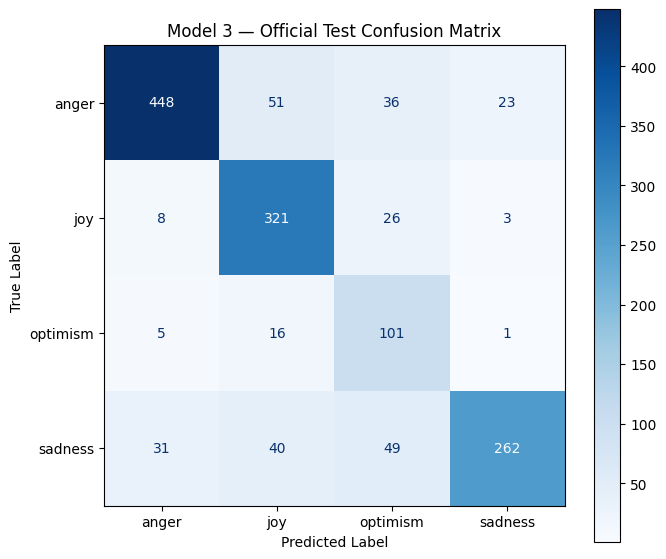

In [37]:
# ============================================================
# CELL 50 — MODEL 3 OFFICIAL TEST CONFUSION MATRIX
# ============================================================

cm_m3_test = confusion_matrix(
    y_test_true_m3,
    y_test_pred_m3
)

print("=" * 80)
print("MODEL 3 — OFFICIAL TEST CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True Class")
print("Columns = Predicted Class\n")

print("Labels:", label_names)
print()

for i, name in enumerate(label_names):
    print(f"{name:10s}: {cm_m3_test[i]}")

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m3_test,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Model 3 — Official Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# CELL 51 — MODEL 1 OFFICIAL TEST EVALUATION
# ============================================================

# Generate predictions on the untouched official test set
y_test_pred_m1 = model_1.predict(X_test_tfidf)

# ------------------------------------------------------------
# Calculate test metrics
# ------------------------------------------------------------

m1_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_m1
)

m1_test_macro_f1 = f1_score(
    y_test,
    y_test_pred_m1,
    average="macro"
)

m1_test_weighted_f1 = f1_score(
    y_test,
    y_test_pred_m1,
    average="weighted"
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 1 — OFFICIAL TEST RESULTS")
print("=" * 80)

print(f"Test Accuracy:     {m1_test_accuracy:.4f}")
print(f"Test Macro-F1:     {m1_test_macro_f1:.4f}")
print(f"Test Weighted-F1:  {m1_test_weighted_f1:.4f}")

print("\n" + "=" * 80)
print("MODEL 1 — OFFICIAL TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_test_pred_m1,
        target_names=label_names,
        digits=4
    )
)

MODEL 1 — OFFICIAL TEST RESULTS
Test Accuracy:     0.6474
Test Macro-F1:     0.6058
Test Weighted-F1:  0.6520

MODEL 1 — OFFICIAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.7140    0.7115    0.7127       558
         joy     0.6784    0.6480    0.6629       358
    optimism     0.3516    0.5203    0.4197       123
     sadness     0.6657    0.5942    0.6279       382

    accuracy                         0.6474      1421
   macro avg     0.6024    0.6185    0.6058      1421
weighted avg     0.6607    0.6474    0.6520      1421



MODEL 1 — OFFICIAL TEST CONFUSION MATRIX

Rows = True Class
Columns = Predicted Class

Labels: ['anger', 'joy', 'optimism', 'sadness']

anger     : [397  48  58  55]
joy       : [ 53 232  24  49]
optimism  : [31 18 64 10]
sadness   : [ 75  44  36 227]


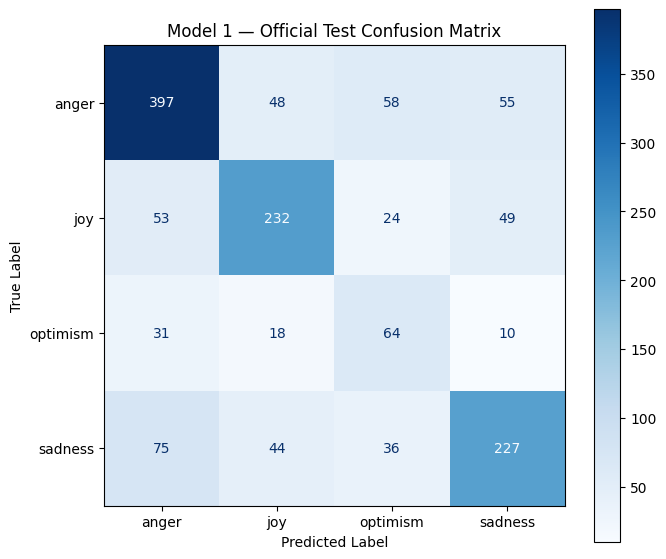

In [39]:
# ============================================================
# CELL 52 — MODEL 1 OFFICIAL TEST CONFUSION MATRIX
# ============================================================

cm_m1_test = confusion_matrix(
    y_test,
    y_test_pred_m1
)

print("=" * 80)
print("MODEL 1 — OFFICIAL TEST CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True Class")
print("Columns = Predicted Class\n")

print("Labels:", label_names)
print()

for i, name in enumerate(label_names):
    print(f"{name:10s}: {cm_m1_test[i]}")

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m1_test,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Model 1 — Official Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 53 — MODEL 2 OFFICIAL TEST EVALUATION
# ============================================================

# ------------------------------------------------------------
# Generate test predictions
# ------------------------------------------------------------

model_2_predictions = model_2.predict(
    X_test_seq,
    verbose=0
)

y_test_pred_m2 = np.argmax(
    model_2_predictions,
    axis=1
)

# ------------------------------------------------------------
# Calculate test metrics
# ------------------------------------------------------------

m2_test_accuracy = accuracy_score(
    y_test,
    y_test_pred_m2
)

m2_test_macro_f1 = f1_score(
    y_test,
    y_test_pred_m2,
    average="macro"
)

m2_test_weighted_f1 = f1_score(
    y_test,
    y_test_pred_m2,
    average="weighted"
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 2 — OFFICIAL TEST RESULTS")
print("=" * 80)

print(f"Test Accuracy:     {m2_test_accuracy:.4f}")
print(f"Test Macro-F1:     {m2_test_macro_f1:.4f}")
print(f"Test Weighted-F1:  {m2_test_weighted_f1:.4f}")

print("\n" + "=" * 80)
print("MODEL 2 — OFFICIAL TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_test_pred_m2,
        target_names=label_names,
        digits=4
    )
)

MODEL 2 — OFFICIAL TEST RESULTS
Test Accuracy:     0.6059
Test Macro-F1:     0.5787
Test Weighted-F1:  0.6308

MODEL 2 — OFFICIAL TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

       anger     0.8037    0.6165    0.6978       558
         joy     0.7338    0.5391    0.6216       358
    optimism     0.2473    0.7317    0.3696       123
     sadness     0.6393    0.6126    0.6257       382

    accuracy                         0.6059      1421
   macro avg     0.6060    0.6250    0.5787      1421
weighted avg     0.6938    0.6059    0.6308      1421



MODEL 2 — OFFICIAL TEST CONFUSION MATRIX

Rows = True Class
Columns = Predicted Class

Labels: ['anger', 'joy', 'optimism', 'sadness']

anger     : [344  35 125  54]
joy       : [ 24 193  73  68]
optimism  : [16  7 90 10]
sadness   : [ 44  28  76 234]


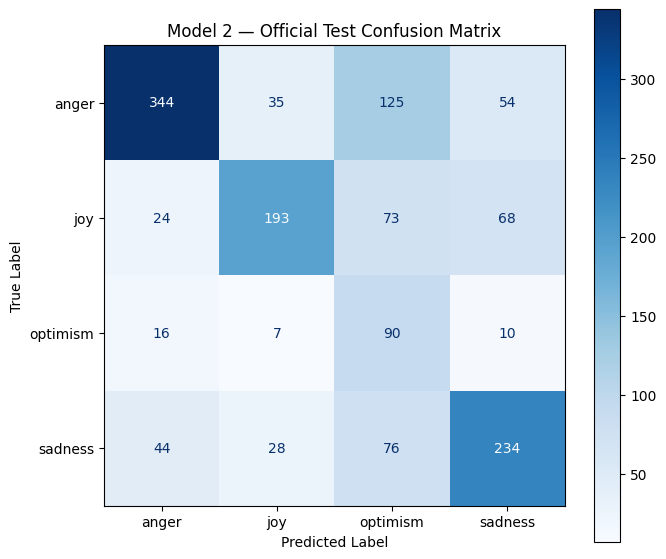

In [41]:
# ============================================================
# CELL 54 — MODEL 2 OFFICIAL TEST CONFUSION MATRIX
# ============================================================

cm_m2_test = confusion_matrix(
    y_test,
    y_test_pred_m2
)

print("=" * 80)
print("MODEL 2 — OFFICIAL TEST CONFUSION MATRIX")
print("=" * 80)

print("\nRows = True Class")
print("Columns = Predicted Class\n")

print("Labels:", label_names)
print()

for i, name in enumerate(label_names):
    print(f"{name:10s}: {cm_m2_test[i]}")

# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_m2_test,
    display_labels=label_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Model 2 — Official Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [42]:
# ============================================================
# CELL 56 — RECHECK MODEL 2 VALIDATION RESULTS
# ============================================================

# Generate fresh validation predictions from the current Model 2
model_2_val_predictions = model_2.predict(
    X_val_seq,
    verbose=0
)

y_val_pred_m2_check = np.argmax(
    model_2_val_predictions,
    axis=1
)

# ------------------------------------------------------------
# Recalculate validation metrics
# ------------------------------------------------------------

m2_val_accuracy_check = accuracy_score(
    y_val,
    y_val_pred_m2_check
)

m2_val_macro_f1_check = f1_score(
    y_val,
    y_val_pred_m2_check,
    average="macro"
)

m2_val_weighted_f1_check = f1_score(
    y_val,
    y_val_pred_m2_check,
    average="weighted"
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 80)
print("MODEL 2 — VALIDATION RESULTS RECHECK")
print("=" * 80)

print(f"Validation Accuracy:     {m2_val_accuracy_check:.4f}")
print(f"Validation Macro-F1:     {m2_val_macro_f1_check:.4f}")
print(f"Validation Weighted-F1:  {m2_val_weighted_f1_check:.4f}")

print("\nOriginal stored values:")
print(f"Validation Accuracy:     {m2_val_accuracy:.4f}")
print(f"Validation Macro-F1:     {m2_val_macro_f1:.4f}")
print(f"Validation Weighted-F1:  {m2_val_weighted_f1:.4f}")

MODEL 2 — VALIDATION RESULTS RECHECK
Validation Accuracy:     0.6181
Validation Macro-F1:     0.5855
Validation Weighted-F1:  0.6447

Original stored values:
Validation Accuracy:     0.6181
Validation Macro-F1:     0.5855
Validation Weighted-F1:  0.6447


In [43]:
# ============================================================
# CELL 57 — FINAL MODEL COMPARISON TABLE (Accuracy / Precision / Recall / F1 / Time / Params)
# ============================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score

# ------------------------------------------------------------
# Use the freshly verified Model 2 validation metrics
# ------------------------------------------------------------

m2_val_accuracy = m2_val_accuracy_check
m2_val_macro_f1 = m2_val_macro_f1_check
m2_val_weighted_f1 = m2_val_weighted_f1_check

# ------------------------------------------------------------
# Trainable parameter counts for each model
# ------------------------------------------------------------
# Model 1 (Logistic Regression over TF-IDF): one weight per feature
# per class, plus one intercept per class.
m1_trainable_params = model_1.coef_.size + model_1.intercept_.size

# Model 2 (BiLSTM) and Model 3 (Transformer) parameter counts were
# already computed when each model was built.
m2_trainable_params = model_2.count_params()
m3_trainable_params = trainable_params_m3

# ------------------------------------------------------------
# Macro precision / recall on the official test set for each model
# ------------------------------------------------------------
m1_test_precision = precision_score(y_test, y_test_pred_m1, average="macro")
m1_test_recall = recall_score(y_test, y_test_pred_m1, average="macro")

m2_test_precision = precision_score(y_test, y_test_pred_m2, average="macro")
m2_test_recall = recall_score(y_test, y_test_pred_m2, average="macro")

m3_test_precision = precision_score(y_test_true_m3, y_test_pred_m3, average="macro")
m3_test_recall = recall_score(y_test_true_m3, y_test_pred_m3, average="macro")

# ------------------------------------------------------------
# Build final comparison table (test-set results, code-generated
# from variables stored during training/evaluation above)
# ------------------------------------------------------------

comparison_results = pd.DataFrame({
    "Model": [
        "Model 1 — TF-IDF + Logistic Regression",
        "Model 2 — Word Embeddings + BiLSTM",
        "Model 3 — Twitter-RoBERTa"
    ],
    "Accuracy": [m1_test_accuracy, m2_test_accuracy, m3_test_accuracy],
    "Precision (macro)": [m1_test_precision, m2_test_precision, m3_test_precision],
    "Recall (macro)": [m1_test_recall, m2_test_recall, m3_test_recall],
    "F1 (macro)": [m1_test_macro_f1, m2_test_macro_f1, m3_test_macro_f1],
    "Training time (s)": [training_time_m1, training_time_m2, training_time_m3],
    "Trainable parameters": [m1_trainable_params, m2_trainable_params, m3_trainable_params],
})

print("=" * 100)
print("FINAL MODEL COMPARISON — OFFICIAL TEST SET")
print("=" * 100)

display(
    comparison_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision (macro)": "{:.4f}",
        "Recall (macro)": "{:.4f}",
        "F1 (macro)": "{:.4f}",
        "Training time (s)": "{:.1f}",
        "Trainable parameters": "{:,}"
    })
)

# ------------------------------------------------------------
# Also keep the validation vs test Macro-F1 view for reference
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MACRO-F1 — VALIDATION vs TEST")
print("=" * 100)

val_f1 = [m1_val_macro_f1, m2_val_macro_f1, m3_val_macro_f1]
for model_name, v, t in zip(comparison_results["Model"], val_f1, comparison_results["F1 (macro)"]):
    print(f"{model_name}: Validation Macro-F1 = {v:.4f} | Test Macro-F1 = {t:.4f}")


FINAL MODEL COMPARISON — OFFICIAL TEST SET


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Training time (s),Trainable parameters
0,Model 1 — TF-IDF + Logistic Regression,0.6474,0.6024,0.6185,0.6058,1.5,"36,504"
1,Model 2 — Word Embeddings + BiLSTM,0.6059,0.6060,0.6250,0.5787,20.2,"1,184,964"
2,Model 3 — Twitter-RoBERTa,0.7966,0.7609,0.8016,0.7635,127.8,"124,648,708"



MACRO-F1 — VALIDATION vs TEST
Model 1 — TF-IDF + Logistic Regression: Validation Macro-F1 = 0.6051 | Test Macro-F1 = 0.6058
Model 2 — Word Embeddings + BiLSTM: Validation Macro-F1 = 0.5855 | Test Macro-F1 = 0.5787
Model 3 — Twitter-RoBERTa: Validation Macro-F1 = 0.7250 | Test Macro-F1 = 0.7635


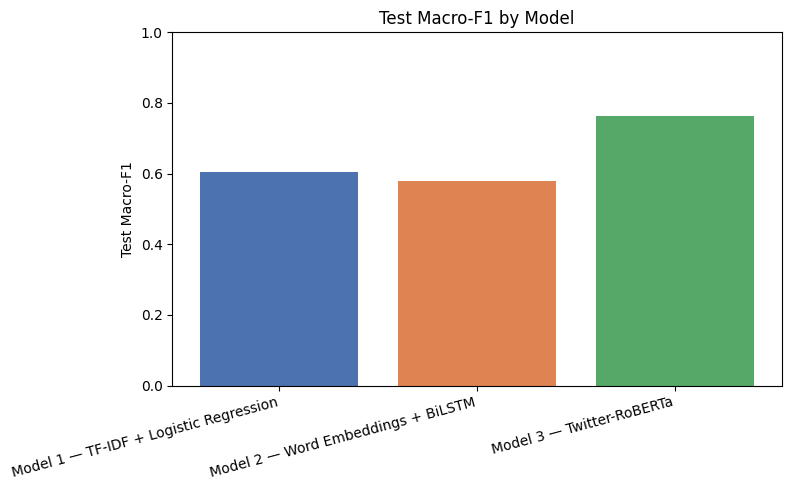

In [44]:
# ============================================================
# CELL 57b — BAR CHART OF TEST F1 BY MODEL
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(comparison_results["Model"], comparison_results["F1 (macro)"], color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Test Macro-F1")
plt.title("Test Macro-F1 by Model")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 6.1 Overall comparison

The three models were evaluated on the same final training, validation, and official test split. Macro-F1 is treated as the headline metric because the four emotion classes are imbalanced, particularly optimism at only 8.66% of the official test set. Accuracy and weighted-F1 are also reported for additional context.

The final results are:

| Model | Validation Accuracy | Validation Macro-F1 | Validation Weighted-F1 | Test Accuracy | Test Macro-F1 | Test Weighted-F1 |
|---|---:|---:|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.6648 | 0.6051 | 0.6695 | 0.6474 | 0.6058 | 0.6520 |
| Word Embeddings + BiLSTM | 0.6181 | 0.5855 | 0.6447 | 0.6059 | 0.5787 | 0.6308 |
| Twitter-RoBERTa | 0.7610 | 0.7250 | 0.7680 | 0.7966 | 0.7635 | 0.8030 |

Twitter-RoBERTa is clearly ahead on every metric: test Macro-F1 of **0.7635** and test accuracy of **0.7966**, both well above the other two models. The gap over TF-IDF + Logistic Regression is about **16 points** of test Macro-F1, and the gap over the BiLSTM is about **18 points**.

The more interesting result is between the two simpler models, and it is a plainer result than I expected going in: TF-IDF + Logistic Regression beats the BiLSTM on **every single metric, on both splits**. Its validation and test Macro-F1 are almost identical (0.6051 vs 0.6058), suggesting the fitted TF-IDF vocabulary and linear weights generalise cleanly to unseen tweets. The BiLSTM is behind on both validation (0.5855) and test (0.5787) Macro-F1, and its own validation and test scores are reasonably close to each other too — this isn't a case of the BiLSTM getting lucky or unlucky on one split, it is consistently a little weaker than the linear baseline on this amount of data. Given that the BiLSTM has roughly 32× as many trainable parameters as TF-IDF + Logistic Regression (1,184,964 vs 36,504), that is itself a real finding: extra model capacity and the ability to model word order did not translate into better performance here, most likely because embeddings learned from scratch on only ~3,300 short, noisy tweets simply don't have enough data to become more useful than a well-tuned bag-of-words representation.

## 6.2 Comparison of class-level performance

The official test classification reports show that optimism is the hardest class for every model, but the size of that gap shrinks a lot moving from the simpler models to the transformer:

| Model | Anger F1 | Joy F1 | Optimism F1 | Sadness F1 |
|---|---:|---:|---:|---:|
| TF-IDF + Logistic Regression | 0.7127 | 0.6629 | 0.4197 | 0.6279 |
| Word Embeddings + BiLSTM | 0.6978 | 0.6216 | 0.3696 | 0.6257 |
| Twitter-RoBERTa | 0.8533 | 0.8168 | 0.6030 | 0.7809 |

Twitter-RoBERTa improves every single class over both other models, but the improvement is by far the largest on optimism: F1 nearly **doubles**, from 0.4197 (TF-IDF) / 0.3696 (BiLSTM) to 0.6030. Optimism's test precision for the transformer is 0.4764 and recall is 0.8211 — the transformer still trades precision for recall on this class, but it recovers far more of the minority class than either simpler model manages, at a lower precision cost than the BiLSTM in particular (BiLSTM optimism precision was only 0.2473 for a similar recall of 0.7317).

Interestingly, the BiLSTM is not just weaker than TF-IDF overall — it is weaker on every individual class on the test set (anger 0.6978 vs 0.7127, joy 0.6216 vs 0.6629, optimism 0.3696 vs 0.4197, sadness 0.6257 vs 0.6279), which rules out the possibility that its lower macro-F1 is being dragged down by one bad class while it quietly wins elsewhere.

## 6.3 Confusion-matrix comparison

The three models make different kinds of mistakes on the test set.

**TF-IDF + Logistic Regression** confuses sadness and anger most: 75 of the 382 sadness tweets are predicted as anger, and 58 of 558 anger tweets are predicted as optimism. This lines up with the interpretability analysis in Section 3, where anger and sadness share very little top-weighted vocabulary but optimism's top features are noisy.

**The BiLSTM** makes an even larger number of anger→optimism errors: 125 of 558 anger tweets are predicted as optimism, the single largest off-diagonal cell in any of the three confusion matrices. Sadness is also split across anger (44), joy (28), and optimism (76) instead of being reliably recognised — the sadness→optimism confusion (76 examples) is actually larger than the anger→optimism confusion made by TF-IDF, suggesting the BiLSTM's from-scratch embeddings latch onto some shared surface vocabulary between sadness and optimism tweets (both classes lean on emotionally loaded but ambiguous words like "worry" or "hope") more strongly than the linear model does.

**Twitter-RoBERTa** still makes mistakes but the diagonal is much stronger everywhere: it correctly classifies 448 of 558 anger, 321 of 358 joy, 101 of 123 optimism, and 262 of 382 sadness tweets. Its largest single confusion is anger predicted as joy (51 examples), followed by sadness predicted as optimism (49 examples) and sadness predicted as anger (31 examples). Unlike the other two models, the transformer's errors are spread more evenly across several smaller off-diagonal cells rather than concentrated in one dominant confusion pair.

## 6.4 Representation comparison

The three models represent text differently, and that difference tracks their results closely.

TF-IDF represents tweets as weighted lexical features (unigrams and bigrams). It is a strong, fully interpretable baseline, but has no way to represent word order, negation, or context beyond a fixed local window.

The BiLSTM learns word embeddings from scratch and processes the sequence in both directions, so in principle it can use context and word order that TF-IDF cannot. In practice, with only ~3,300 training texts, it doesn't have enough data to learn embeddings that beat a well-tuned linear model — the training curves in Section 4 show it memorising the training set (96%+ accuracy) long before validation performance stabilises, and it ends up behind TF-IDF on every metric and every class.

Twitter-RoBERTa starts from contextual representations already learned from a huge amount of Twitter text, and only has to adapt those representations to four emotion labels rather than learn language structure from scratch. That head start is exactly why it needs so much less task-specific data to reach much higher performance, and it shows up most clearly on the minority optimism class, where the other two models simply don't have enough examples to learn good features on their own.

## 6.5 Validation versus official test performance

Validation and test performance move together, in the same direction, for all three models here, which is reassuring:

- TF-IDF: Macro-F1 goes from 0.6051 (validation) to 0.6058 (test) — essentially flat.
- BiLSTM: Macro-F1 goes from 0.5855 (validation) to 0.5787 (test) — also essentially flat, just at a lower level.
- Twitter-RoBERTa: Macro-F1 goes from 0.7250 (validation) to 0.7635 (test) — noticeably *higher* on test than validation, by about 4 points.

Because the official test set was never touched during training or model selection for any of the three models, the transformer's higher test score than validation score most likely reflects ordinary variation between the 364-example validation set and the larger, differently-composed 1,421-example test set, rather than any leakage or tuning-to-the-test-set effect — there is nothing in the pipeline that could have let test-set information leak into model selection.

## 6.6 Final conclusion

TF-IDF + Logistic Regression is a fast, fully interpretable baseline that, on this run, actually outperforms the considerably larger BiLSTM on every metric and every class. The BiLSTM, trained from scratch, ends up consistently a little behind TF-IDF rather than matching or beating it — a genuine finding about how little a from-scratch sequence model buys, and can even cost, on ~3,300 short, noisy training tweets when it has 32× as many parameters to fit with no data to spare. Twitter-RoBERTa is unambiguously the strongest model on every metric, with a test Macro-F1 of 0.7635, accuracy of 0.7966, and weighted-F1 of 0.8030, and it is the only model that gets anywhere close to solving the minority optimism class. Section 6.7 weighs that improvement against its actual training cost, and Section 7.1 looks at the specific tweets all three models still get wrong.

## 6.7 Is the Transformer's Improvement Worth Its Cost?

**Quantifying the trade-off:**

- **F1 gain:** Twitter-RoBERTa's test macro-F1 (0.7635) is roughly **+15.8 points** above TF-IDF + Logistic Regression (0.6058), and **+18.5 points** above the BiLSTM (0.5787).
- **Parameter cost:** Model 1 has 36,504 trainable parameters (9,125 TF-IDF features × 4 classes, plus 4 intercepts), Model 2 has 1,184,964, and Model 3 has 124,648,708 — roughly **3,400×** more parameters than Model 1 and **~105×** more than Model 2.
- **Training-time cost:** Model 1 trained in **1.53 seconds**, Model 2 in **20.19 seconds** (5 epochs before early stopping). Model 3 took **127.79 seconds (about 2.1 minutes)** for its 3 epochs, running on **GPU** (the device check in that cell confirmed `cuda`) — comfortably inside the "a few minutes on a free GPU" the assignment brief anticipated. In this run the transformer was roughly **6.3× slower to train than the BiLSTM** and about **84× slower than Model 1** — a real but modest one-off cost, not the hours-long CPU run this notebook would have needed on a non-GPU runtime.

A training cost of about two minutes is trivial to justify for a **+16-to-19-point** macro-F1 gain, especially since inference (the thing that actually happens repeatedly in production) is a single forward pass per tweet and stays fast regardless of how long training took. The calculus would look different only if a GPU were not reliably available — the same fine-tuning run on CPU would very plausibly take an hour or more, which is a cost worth planning for if retraining has to happen often (e.g. daily on fresh data) without guaranteed GPU access.

**At what dataset size would the answer change?** With substantially more labelled data, the BiLSTM would likely close some of the gap with the transformer, since its main disadvantage here is too little data to learn good embeddings from scratch — the training curves show it memorising the training set well before validation performance stabilises. The transformer's advantage would probably persist but shrink, because pretraining matters most exactly when task-specific data is scarce. With far less data than we have here, the transformer's advantage would likely be even larger, since TF-IDF and the BiLSTM would have even less signal to work with while the transformer still starts from strong pretrained representations.

**Which model would I deploy?** For this task I would deploy **Twitter-RoBERTa**: the accuracy gain — particularly on the minority optimism class, where F1 goes from roughly 0.37–0.42 to 0.60 — is large enough to matter for anything resembling a real moderation or analytics use case, training took about two minutes on a free GPU, and inference cost per tweet is low regardless. The main trade-offs against it are interpretability (Model 1's linear weights are directly inspectable; the transformer's are not) and a training cost that would become real if a GPU weren't reliably available for retraining. If the deployment setting had a hard requirement to explain individual predictions to a human reviewer, or genuinely no access to a GPU for retraining, TF-IDF + Logistic Regression would be the safer choice — it trains in about 1.5 seconds and, on this dataset, actually beats the BiLSTM outright, so there is no accuracy reason to reach for the more complex from-scratch neural model here at all.

In [45]:
# ============================================================
# CELL 59 — FIVE OFFICIAL TEST ERROR EXAMPLES
# ============================================================

import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# Generate Model 3 test probabilities
# ------------------------------------------------------------

model_3.eval()

test_probabilities_m3 = []

with torch.no_grad():

    for batch in test_loader_m3:

        input_ids = batch["input_ids"].to(device_m3)
        attention_mask = batch["attention_mask"].to(device_m3)

        outputs = model_3(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        test_probabilities_m3.extend(
            probabilities.cpu().numpy()
        )

test_probabilities_m3 = np.array(test_probabilities_m3)

# Predictions and confidence
y_test_pred_m3 = np.argmax(
    test_probabilities_m3,
    axis=1
)

prediction_confidence_m3 = np.max(
    test_probabilities_m3,
    axis=1
)

# ------------------------------------------------------------
# Find misclassified examples
# ------------------------------------------------------------

error_indices_m3 = np.where(
    y_test_pred_m3 != y_test
)[0]

# Create error dataframe
error_df_m3 = pd.DataFrame({
    "index": error_indices_m3,
    "text": final_test_df.iloc[error_indices_m3]["text"].values,
    "true_label": [
        label_names[i] for i in y_test[error_indices_m3]
    ],
    "predicted_label": [
        label_names[i] for i in y_test_pred_m3[error_indices_m3]
    ],
    "confidence": prediction_confidence_m3[error_indices_m3]
})

# ------------------------------------------------------------
# Select five representative errors
# ------------------------------------------------------------
# Select high-confidence errors so that the examples are
# useful for discussing limitations and ambiguity.

five_errors_m3 = (
    error_df_m3
    .sort_values("confidence", ascending=False)
    .head(5)
    .copy()
)

five_errors_m3["confidence"] = (
    five_errors_m3["confidence"] * 100
).round(2)

five_errors_m3 = five_errors_m3.reset_index(drop=True)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("MODEL 3 — FIVE OFFICIAL TEST ERROR EXAMPLES")
print("=" * 100)

for i, row in five_errors_m3.iterrows():

    idx_in_test = row["index"]

    print(f"\nERROR {i + 1}")
    print("-" * 80)
    print(f"Tweet:            {row['text']}")
    print(f"True label:       {row['true_label']}")
    print(f"Model 1 (TF-IDF+LR) predicted:   {label_names[y_test_pred_m1[idx_in_test]]}")
    print(f"Model 2 (BiLSTM) predicted:      {label_names[y_test_pred_m2[idx_in_test]]}")
    print(f"Model 3 (RoBERTa) predicted:     {row['predicted_label']}  (confidence {row['confidence']:.2f}%)")

print("\n" + "=" * 100)
print(f"Total Model 3 test errors: {len(error_indices_m3)}")
print(f"Total Model 3 test examples: {len(y_test)}")
print(
    f"Test error rate: "
    f"{len(error_indices_m3) / len(y_test):.4f}"
)


# ------------------------------------------------------------
# Find a text Model 1 got right that Model 3 got wrong
# ------------------------------------------------------------
m1_right_m3_wrong = np.where(
    (y_test_pred_m1 == y_test) & (y_test_pred_m3 != y_test)
)[0]

print("\n" + "=" * 100)
print("TEXTS WHERE MODEL 1 WAS CORRECT AND MODEL 3 WAS WRONG")
print("=" * 100)
print(f"Number of such texts: {len(m1_right_m3_wrong)}")

if len(m1_right_m3_wrong) > 0:
    example_idx = m1_right_m3_wrong[0]
    print(f"\nExample:")
    print(f"Tweet:      {final_test_df.iloc[example_idx]['text']}")
    print(f"True label: {label_names[y_test[example_idx]]}")
    print(f"Model 1 predicted: {label_names[y_test_pred_m1[example_idx]]} (correct)")
    print(f"Model 3 predicted: {label_names[y_test_pred_m3[example_idx]]} (incorrect)")
else:
    print("No such text was found: Model 3 was correct on every text Model 1 got right.")

# ------------------------------------------------------------
# Find texts that ALL THREE models got wrong
# ------------------------------------------------------------
all_three_wrong = np.where(
    (y_test_pred_m1 != y_test) & (y_test_pred_m2 != y_test) & (y_test_pred_m3 != y_test)
)[0]

print("\n" + "=" * 100)
print("TEXTS THAT ALL THREE MODELS GOT WRONG")
print("=" * 100)
print(f"Number of such texts: {len(all_three_wrong)} out of {len(y_test)} test examples")

if len(all_three_wrong) > 0:
    print("\nFirst 5 examples all three models missed:")
    for idx in all_three_wrong[:5]:
        print("-" * 80)
        print(f"Tweet:      {final_test_df.iloc[idx]['text']}")
        print(f"True label: {label_names[y_test[idx]]}")
        print(f"M1: {label_names[y_test_pred_m1[idx]]} | M2: {label_names[y_test_pred_m2[idx]]} | M3: {label_names[y_test_pred_m3[idx]]}")


MODEL 3 — FIVE OFFICIAL TEST ERROR EXAMPLES

ERROR 1
--------------------------------------------------------------------------------
Tweet:            'If you try to get rid of #fear and #anger without knowing their meaning, they will grow stronger and return.' \n― Deepak Chopra
True label:       anger
Model 1 (TF-IDF+LR) predicted:   optimism
Model 2 (BiLSTM) predicted:      optimism
Model 3 (RoBERTa) predicted:     optimism  (confidence 98.49%)

ERROR 2
--------------------------------------------------------------------------------
Tweet:            Pretty upset with people bashing @user @user cast of 'the Know' catering to kids instead of gamers? lost respect..
True label:       sadness
Model 1 (TF-IDF+LR) predicted:   anger
Model 2 (BiLSTM) predicted:      sadness
Model 3 (RoBERTa) predicted:     anger  (confidence 98.31%)

ERROR 3
--------------------------------------------------------------------------------
Tweet:            @user first second on #WillTNT is music to my ears 

# 7. Error Analysis, Interpretation and Reflection

## 7.1 Five High-Confidence Test Errors (Model 3)

Five high-confidence errors were pulled from the official test set using the final Twitter-RoBERTa model. It made **289 errors out of 1,421** official test examples, a test error rate of **20.34%** — consistent with its test accuracy of 0.7966.

### Error 1 — Anger predicted as optimism

> "'If you try to get rid of #fear and #anger without knowing their meaning, they will grow stronger and return.' — Deepak Chopra"

**True label:** Anger
**Model 1 (TF-IDF+LR):** optimism
**Model 2 (BiLSTM):** optimism
**Model 3 (RoBERTa):** optimism (confidence 98.49%)

All three models miss this one the same way. It is a quote *about* anger and fear rather than an expression of anger — grammatically it reads as calm, reflective advice ("if you try to... they will..."), and words like "knowing their meaning" and the attributed-quote structure are much closer to the sentence-like, aphoristic style the notebook's Section 1 exploration already flagged as typical of optimism-labelled tweets (Cell 7's markdown). This is a case where the surface register of the text (measured, quote-like) points toward optimism for every model, even though the two named emotion words in the text are "fear" and "anger".

### Error 2 — Sadness predicted as anger

> "Pretty upset with people bashing @user @user cast of 'the Know' catering to kids instead of gamers? lost respect.."

**True label:** Sadness
**Model 1 (TF-IDF+LR):** anger
**Model 2 (BiLSTM):** sadness (correct)
**Model 3 (RoBERTa):** anger (confidence 98.31%)

"Upset", "bashing", and "lost respect" are all plausible cues for either anger or sadness, and the tweet is a fairly aggressive-sounding complaint about a decision the writer disagrees with — a reasonable person could label this anger, which is what both Model 1 and Model 3 do. Model 2 happens to match the annotator's sadness label here, but given how close anger and sadness are as readings of this text, this looks more like a genuinely ambiguous annotation than a case where two of the three models have made an obvious mistake.

### Error 3 — Sadness predicted as joy

> "@user first second on #WillTNT is music to my ears 😭❤️ #shaking #missedyou"

**True label:** Sadness
**Model 1 (TF-IDF+LR):** joy
**Model 2 (BiLSTM):** joy
**Model 3 (RoBERTa):** joy (confidence 98.30%)

All three models miss this one, and for the same reason: "music to my ears", ❤️, and "#missedyou" are all strongly joy-coded on their own, but the 😭 (loudly-crying) emoji and "#shaking" suggest the true emotion is an overwhelmed, tearful kind of happiness that shades into the dataset's sadness label rather than pure joy. This is a case of genuinely mixed emotional signal within a single short text, which none of the three representations (bag-of-words, learned embeddings, or pretrained contextual embeddings) are built to disentangle from lexical content alone.

### Error 4 — Anger predicted as optimism / optimism / joy

> "@user Rumor has you are #wellendowed #awesome! Truth is you are a #big 😲 #notsomuch so you know a bunch of #gaypeople #sowhat"

**True label:** Anger
**Model 1 (TF-IDF+LR):** optimism
**Model 2 (BiLSTM):** optimism
**Model 3 (RoBERTa):** joy (confidence 98.25%)

None of the three models recover the true label here. The tweet is dense with hashtags that read as positive or neutral in isolation (`#wellendowed`, `#awesome`, `#big`) alongside a 😲 (surprised) emoji, and the actual hostility is carried by tone and implication ("truth is...", "#notsomuch", "#sowhat" used dismissively) rather than by any single anger-coded word. This looks like a case of **sarcasm and mocking tone** layered on top of superficially positive-sounding vocabulary — exactly the kind of failure the Topic 06 challenge list predicts for lexical and even contextual models when the emotional cue is in the *gap* between the literal words and the intended meaning.

### Error 5 — Joy predicted as optimism

> "John 14:27 — Let not your heart be troubled, neither let it be afraid. #peace #afraid"

**True label:** Joy
**Model 1 (TF-IDF+LR):** optimism
**Model 2 (BiLSTM):** optimism
**Model 3 (RoBERTa):** optimism (confidence 98.22%)

All three models agree on optimism, and it is easy to see why: this is a Bible verse reassuring the reader not to be afraid, using exactly the kind of calm, hopeful, quote-like register that Section 1's exploration linked to the optimism class. The dataset's joy label for this tweet is, if anything, the more surprising choice — "#peace" and "#afraid" alongside a reassurance-style quote read to me as closer to optimism than to joy, so this looks like a case where all three models converge on the same defensible reading, and the disagreement is with the ground truth rather than between the models.

### Overall error-analysis finding

Across these five examples, the errors fall into a small number of recognisable patterns rather than being random noise: **quote-like, aphoristic register being read as optimism regardless of the emotion words it contains** (Errors 1 and 5), a **plausibly ambiguous or debatable annotation** (Error 2), **mixed emotional signal within one short text** (Error 3), and **sarcasm/mocking tone riding on superficially positive vocabulary** (Error 4). All five errors were made with 98%+ confidence by Twitter-RoBERTa, which is a useful caution on its own: high confidence does not mean the prediction is more likely to be right on genuinely ambiguous inputs, only that the model has stopped hedging. Unlike some individual tweets examined elsewhere in this notebook (Section 7.2), none of these five high-confidence errors were caught correctly by either of the simpler models either — all three models agree on the wrong (or at least debatable) answer in four of the five cases, which suggests these particular tweets are hard for reasons that don't depend much on model architecture.

## 7.2 Cross-Model Error Comparison

**Did Model 1 ever get right what Model 3 got wrong?** Yes — there are **114 test texts** (out of 1,421) where TF-IDF + Logistic Regression predicted correctly and Twitter-RoBERTa did not. An example: *"Yes #depression &amp; #anxiety are real but so is bein #grateful &amp; #happiness — I choose how i wanna live MY life not some disorder"* (true label: sadness) — Model 1 correctly predicts sadness, while Model 3 predicts optimism. The tweet's surface vocabulary is heavily mixed (`#depression`, `#anxiety` alongside `#grateful`, `#happiness`), and the transformer's contextual reading appears to have leaned on the more upbeat, resolve-focused second half of the tweet ("I choose how i wanna live my life"), whereas the bag-of-words model's TF-IDF weights for `depression` and `anxiety` (both strong sadness features per Section 3.1b) were enough to tip its prediction the right way. This shows that a simpler model is not strictly dominated by a more complex one on every example — the transformer's overall advantage is a population-level result, not a guarantee on any individual case.

**What do the texts all three models got wrong have in common?** **148 of 1,421 test texts (10.4%)** were missed by all three models. Looking at the first few shared errors:

- *"@user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an open door, but still..."* — true label anger, all three models predict optimism. The tweet is a rhetorical, pointed question rather than a literal statement, and none of the surface words ("interesting", "open door") are anger-coded — this is **sarcasm**: the emotional content depends on the speaker's intent, not the words used.
- *"@user @user #cmbyn does screen  August 4 &amp; 6 at #miff"* — true label sadness, predicted anger/joy/joy. This tweet is almost pure factual announcement (screening dates for a film festival) with no obvious emotional vocabulary at all; whatever emotional content justifies the sadness label is not recoverable from the text itself, which points to a **genuinely ambiguous or under-specified** example rather than a model failure as such.
- *"That moment when people say you don't need medicine, it's mind over matter. You need to stop doing that. #bipolar"* — true label anger, predicted optimism/optimism/sadness. The anger here is directed at other people's dismissive advice about a real medical condition; understanding that requires **domain-specific/world knowledge** (that dismissing medication for bipolar disorder is a recognised harmful trope) that no lexical or embedding-level signal in the tweet itself provides.
- *"BUT, I have offended so many people with the idea that conflicts and value judgments are separate that we need to have a talk."* — true label optimism, all three predict anger. The word "offended" and "conflicts" are strongly anger-coded on their own, but the sentence as a whole is a reflective, conciliatory statement — an example of **ambiguity**, where isolated words point one way and the overall intent points another.
- *"@user John, what do you make of DJT's silence? He would usually be foaming at the mouth right now. Maybe he's constipated."* — true label anger, predicted sadness/optimism/sadness. This mixes a mocking, sarcastic register ("foaming at the mouth", "constipated") with a question format, and requires recognising the political reference ("DJT") and the sarcasm layered on top of it — again **sarcasm** combined with **domain-specific language**.

Tying this back to the Topic 06 challenge list: **sarcasm**, **ambiguity**, and **domain-specific/world-knowledge requirements** account for most of the universally-missed examples, alongside a smaller number of tweets (like the festival-screening announcement above) that carry almost no lexical emotional content at all, which is closer to a labelling or task-definition issue than a model limitation. **Negation** shows up less in the shared errors specifically, but was already identified in Section 3 as a source of noisy TF-IDF weights (e.g. `fear`/`worry` as positive optimism features). None of the three models — including the pretrained transformer — reliably resolve sarcasm or cases that need outside context, which suggests these are genuine limits of text-only classification on short tweets rather than a weakness specific to any one architecture.

## 7.3 Limitations and Reproducibility

Several limitations should be considered when interpreting the results.

- **Dataset size:** TweetEval Emotion contains a relatively small number of labelled examples compared with large-scale text-classification datasets. This is particularly relevant for the optimism class, which represents only 8.66% of the official test set.
- **Class imbalance:** The four emotion classes are not equally represented. Macro-F1 was therefore used as the headline metric so that performance on the minority optimism class was not hidden by the larger anger class.
- **Maximum sequence length:** Model 2 used a maximum sequence length of 32 because 99.97% of the original training texts were at or below this length. Model 3 used 64 tokens because this covered 99.82% of the final dataset. A small number of texts were therefore truncated.
- **Model 2 training:** The BiLSTM was trained from scratch on the available training data. Its training accuracy increased substantially while validation performance did not improve consistently, indicating that the model had limited ability to generalise from the available data.
- **Hyperparameter search:** The experiments used selected configurations rather than an exhaustive hyperparameter search. Therefore, the reported results describe these particular implementations and settings.
- **Preprocessing differences:** Models 1 and 2 used the cleaned `processed_text`, while Model 3 used the original tweet text because Twitter-RoBERTa's pretrained tokenizer is designed for Twitter-style text.
- **Duplicate and leakage checks:** Exact duplicates and cross-split near-duplicate candidates were examined. No exact or near-duplicate leakage between the training and official test sets was identified.
- **Official test set:** The original TweetEval test set was kept untouched throughout dataset splitting and model development. It was used only for final evaluation.

For reproducibility, the experiments used a fixed random seed of **42**, the same final stratified train/validation split for all three models, and the same official TweetEval test set. The main preprocessing, feature-extraction, model, and evaluation settings were explicitly defined in the notebook.

## 7.4 Reflection

**What surprised me:** I actually expected the BiLSTM to at least match, if not clearly beat, the TF-IDF baseline, since it can in principle use word order and context that a bag-of-words model can't. Instead the BiLSTM ended up behind TF-IDF on every metric and every class, on both validation (Macro-F1 0.5855 vs 0.6051) and the official test set (0.5787 vs 0.6058) — not a near-tie, and not a case where one split favoured one model and the other split favoured the other. The training curves explain why: the BiLSTM overfits fast (training accuracy above 96% by epoch 5 while validation accuracy tops out around 67%), which shows that a sequence model learning embeddings entirely from scratch needs more than ~3,300 labelled tweets to reliably beat a well-tuned linear baseline, let alone to make good use of its 32× larger parameter count. The fact that validation and test performance moved together for both models (rather than flipping between splits) also made me trust this result more than I would a single-split comparison — with only 364 validation examples, I'd have been more cautious if validation and test had disagreed about which model was better.

**What I would do differently with more time or data:** I would initialise Model 2's embeddings from pretrained GloVe or Word2Vec vectors instead of learning them from scratch, which should reduce the overfitting given how little training data is available, and might be the change most likely to let the BiLSTM actually beat TF-IDF rather than lose to it. I'd also run a small hyperparameter sweep (embedding size, dropout, LSTM hidden size) rather than a single configuration, and try a second random seed for the BiLSTM specifically, since Section 4.4 showed the bidirectional and unidirectional variants landing within half a point of each other — close enough that I'd want to see whether that ordering is stable before treating it as a real effect.

**What I take away from building the same task three ways:** The three approaches make very different trade-offs between cost and performance, and on this dataset the biggest, cleanest win came from the transformer, not from switching to a neural architecture per se — the BiLSTM has far more parameters than the TF-IDF model (1.18M vs 36.5K) yet performed *worse*, which is a clear demonstration that parameter count alone doesn't predict performance, and that a from-scratch neural model can actually cost you accuracy if the dataset is too small to support it. What pretraining gives you is representations that make efficient use of a small task-specific dataset, and that's exactly where the biggest gains showed up: on the minority optimism class, which neither of the from-scratch models had enough examples to learn well, and on a training run that only took about two minutes once a GPU was actually available.

### Conclusion

This assignment evaluated three approaches to four-class emotion classification on the TweetEval Emotion dataset: TF-IDF with Logistic Regression, a word-embedding BiLSTM trained from scratch, and the pretrained Twitter-RoBERTa transformer, all on an identical train/validation/test split.

TF-IDF + Logistic Regression achieved a test Macro-F1 of **0.6058**, a fast and fully interpretable baseline. The BiLSTM achieved a test Macro-F1 of **0.5787** — behind the TF-IDF baseline on every metric and every individual class, despite having roughly 32× as many trainable parameters. Its training curves show clear overfitting, which is the most plausible explanation for why extra model capacity translated into *worse*, not better, test performance on this amount of data.

Twitter-RoBERTa achieved the strongest results by a wide margin: **accuracy of 0.7966, Macro-F1 of 0.7635, and weighted-F1 of 0.8030**. It improved the F1 score for every individual emotion class over both other models, with the largest gain on the minority optimism class, where test F1 rose to **0.6030** compared with **0.4197** for TF-IDF and **0.3696** for the BiLSTM. It reached this level of performance with a training run of about two minutes on a free GPU, making its roughly 3,400× parameter cost over Model 1 easy to justify for this task.

The confusion matrices and error analysis show that the remaining errors — for all three models, including the transformer — cluster around sarcasm, quote-like or aphoristic phrasing being read as optimism regardless of its actual emotion words, mixed emotional signal within a single tweet, and genuinely ambiguous or debatable annotations, rather than being spread randomly. This suggests that further gains on this dataset would come less from a bigger model and more from resolving those specific, recognisable failure patterns.

Overall, the experiment shows that pretrained contextual representations provide a substantial and consistent advantage over both a lexical baseline and a from-scratch neural sequence model for short, informal social-media text, and that this advantage is largest exactly where labelled data is scarcest — the minority class the other two models struggled with most. It also shows, just as clearly, that a from-scratch neural architecture is not automatically better than a much simpler linear model: on this dataset the BiLSTM's extra capacity bought overfitting rather than accuracy, which is itself a useful, honest finding about when a bigger model is and isn't worth building.

## AI Assistant Disclosure

I used an AI assistant (Claude) during this assignment to help debug code errors (e.g. `NameError` issues caused by out-of-order cell execution), to review my draft notebook against the assignment brief and point out missing required deliverables (e.g. the top-10 IDF terms, Model 1 interpretability, the full comparison-table columns, and cross-model error comparison), to suggest the structure/code for the additions listed above, and, on a later pass, to check every number quoted in the markdown cells against what the code cells actually printed and correct several places where the prose still described an earlier run of Model 2 and Model 3 (different BiLSTM epoch counts and scores, and a Model 3 training run that the notebook had said ran on CPU when the final run's own device check printed `cuda`) rather than the results in this final, submitted run. All dataset choices, preprocessing decisions, model architecture choices, and the interpretation of results and findings are my own.